Neste notebook estarei implementando minha primeira GAN que deve ser treinada em cima da base de dados MNIST, e aprender a gerar novas imagens de digitos manuscritos.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import ConcatDataset, DataLoader
import torchvision.transforms as transforms
torch.__version__

'2.10.0+cu130'

In [2]:
torch.manual_seed(123)

Definição do dataset:

In [3]:
transform = transforms.ToTensor()

trainDataset = datasets.MNIST(root = '../', train = True, download = True, 
                       transform = transform)
testDataset = datasets.MNIST(root = '../', train = False, download = True, 
                       transform = transform)
# dataset único
fullDataset = ConcatDataset([trainDataset, testDataset])
loader = DataLoader(fullDataset, batch_size = 128, shuffle = True)

Definição da Rede neural Geradora:

In [4]:
class Gerador(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
                                   # 100 números aleatórios para 64 da 1a camada oculta
                                   nn.Linear(100, 64),
                                   # LeakyReLU: Para numeros positivos funciona como ReLU.
                                   # Para numeros negativos, multiplica a entrada por um slope definido em seu parametro
                                   # Aqui nesse caso, o slope foi 0.2, ou seja:
                                   # Caso a entrada seja negativa, ela será multiplicada por 0.2 para a saída.
                                   # O resultado é um número negativo maior (menos negativo) do que a entrada, caso ela seja negativa.
                                   nn.LeakyReLU(0.2),
                                   nn.Dropout(0.3),

                                   nn.Linear(64, 32),
                                   nn.LeakyReLU(0.2),
                                   nn.Dropout(0.3),

                                   nn.Linear(32, 64),
                                   nn.LeakyReLU(0.2),
                                   nn.Dropout(0.3),

                                   nn.Linear(64, 100),
                                   nn.LeakyReLU(0.2),
                                   nn.Dropout(0.3),

                                   nn.Linear(100, 128),
                                   nn.LeakyReLU(0.2),
                                   nn.Dropout(0.3),
                                   
                                   # 28 * 28: Dimensionalidade das imagens da base MNIST
                                   nn.Linear(128, 28*28),
                                   # Função de ativação da saída: Tangente hiperbolica, saída fica entre -1 e 1.
                                   # Costuma funcionar melhor para GANs pois o treinamento é mais estável e rápido do que Sigmoid,
                                   # Devido ao valor pequeno do gradiente que ocorre em Sigmoid quando os valores estão próximos de 0 ou 1.
                                   # Para usar Tanh, as imagens de treino do discriminador também precisam ficar entre -1 e 1.
                                   nn.Tanh()
                                   )
    def forward(self, X):
        X = self.model(X)
        X = X.view(-1, 1, 28, 28)
        return X

Definição da Rede neural Discriminadora:

In [5]:
class Discriminador(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3,3)),
                                   nn.ReLU(),
                                   nn.BatchNorm2d(num_features=32),
                                   nn.MaxPool2d(kernel_size=(2, 2)),
                                   
                                   nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3)),
                                   nn.ReLU(),
                                   nn.BatchNorm2d(num_features=32),
                                   nn.MaxPool2d(kernel_size=(2, 2)),

                                   nn.Flatten(),

                                   nn.Linear(in_features = 5 * 5 * 32, out_features = 128),
                                   nn.ReLU(),
                                   nn.Dropout(p = 0.2),

                                   nn.Linear(in_features = 128, out_features = 128),
                                   nn.ReLU(),
                                   nn.Dropout(p = 0.2),

                                   # Classificação binaria de imagens de digitos, então saída (depois da função de ativação da ultima camada) será 0 ou 1.
                                   nn.Linear(128, 1)
                                   )
    
    def forward(self, X):
        return self.model(X)
    

Treinamento dos modelos:

In [6]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

G = Gerador().to(device)
D = Discriminador().to(device)

GOptimizer = optim.Adam(G.parameters(), lr = 0.002)
DOptimizer = optim.Adam(D.parameters(), lr = 0.002)

# Aplica Sigmoid intermanete e usa Binary cross entropy
# Segundo a doc do pytorch, é mais estável do que usar BCELoss com uma fç de ativação Sigmoid na ultima camada.
# Logits: Dados não tratados na ultima camada. Ou seja, dados que não passaram ainda por uma fç de ativação na ultima camada.
criterion = nn.BCEWithLogitsLoss()

ÉPOCA 001 finalizada: Loss discriminador 0.351045 - Loss gerador 13.718166      


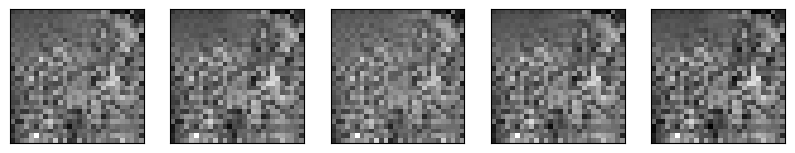

ÉPOCA 002 finalizada: Loss discriminador 0.336169 - Loss gerador 18.724603      


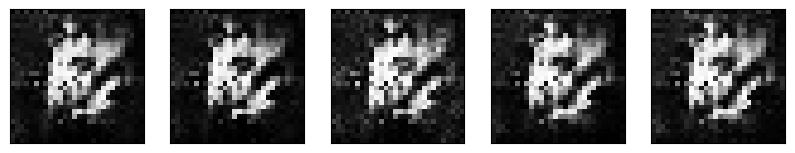

ÉPOCA 003 finalizada: Loss discriminador 0.338099 - Loss gerador 20.817679      


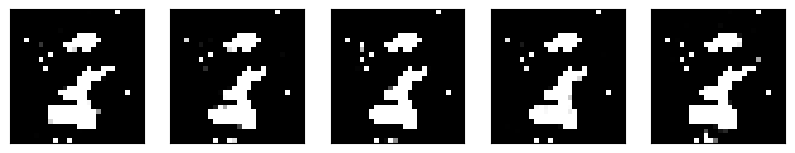

ÉPOCA 004 finalizada: Loss discriminador 0.346055 - Loss gerador 19.262812      


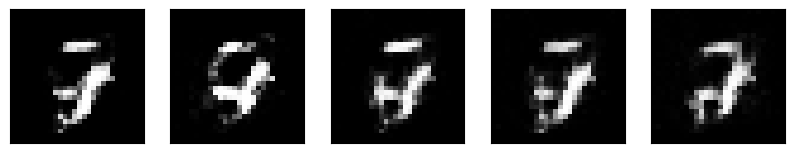

ÉPOCA 005 finalizada: Loss discriminador 0.345552 - Loss gerador 15.964800      


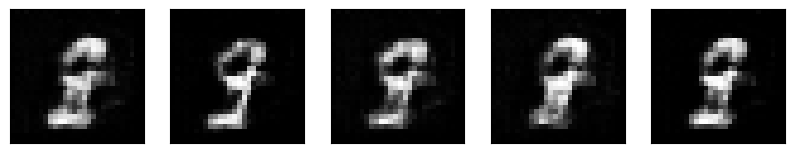

ÉPOCA 006 finalizada: Loss discriminador 0.347386 - Loss gerador 17.843311      


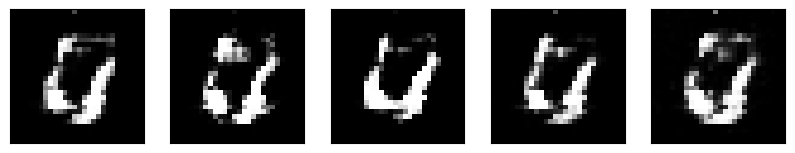

ÉPOCA 007 finalizada: Loss discriminador 0.339827 - Loss gerador 17.879264      


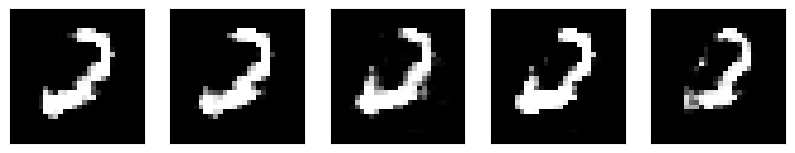

ÉPOCA 008 finalizada: Loss discriminador 0.348065 - Loss gerador 18.999056      


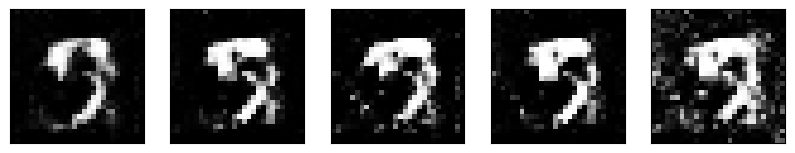

ÉPOCA 009 finalizada: Loss discriminador 0.338412 - Loss gerador 16.599729      


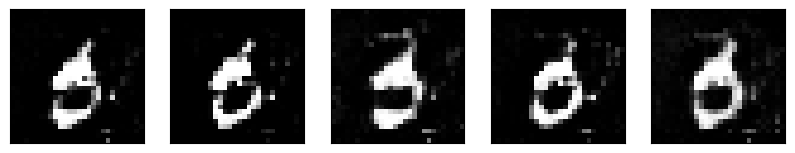

ÉPOCA 010 finalizada: Loss discriminador 0.346072 - Loss gerador 20.790416      


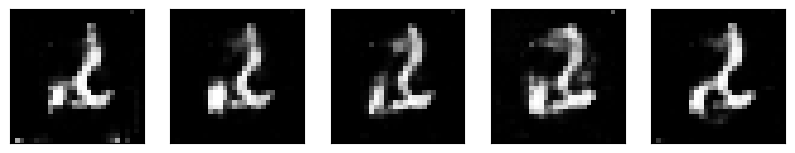

ÉPOCA 011 finalizada: Loss discriminador 0.340111 - Loss gerador 17.441068      


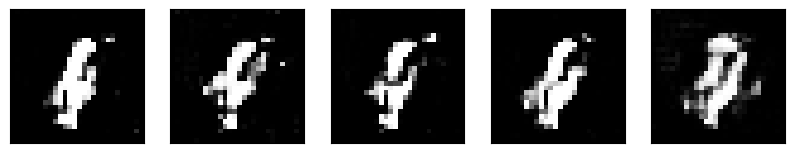

ÉPOCA 012 finalizada: Loss discriminador 0.338542 - Loss gerador 16.121253      


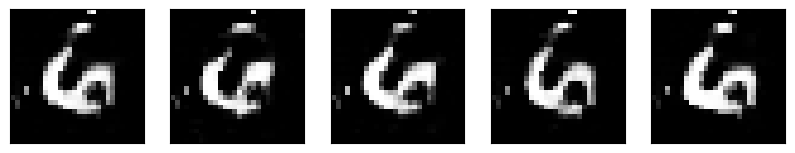

ÉPOCA 013 finalizada: Loss discriminador 0.338984 - Loss gerador 16.968154      


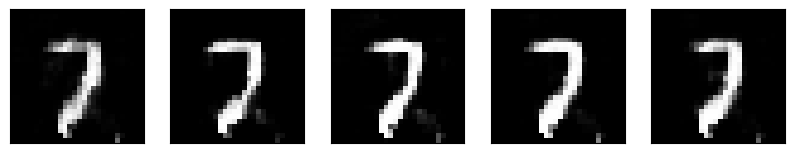

ÉPOCA 014 finalizada: Loss discriminador 0.340699 - Loss gerador 16.852101      


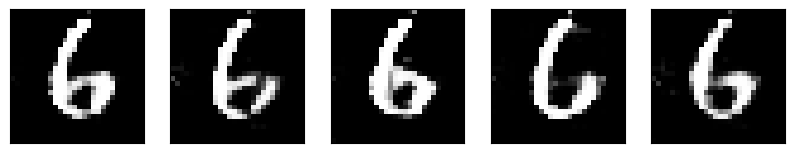

ÉPOCA 015 finalizada: Loss discriminador 0.334910 - Loss gerador 15.990942      


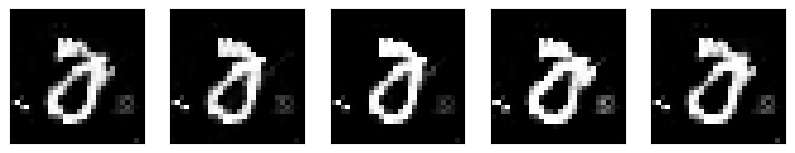

ÉPOCA 016 finalizada: Loss discriminador 0.339563 - Loss gerador 21.357405      


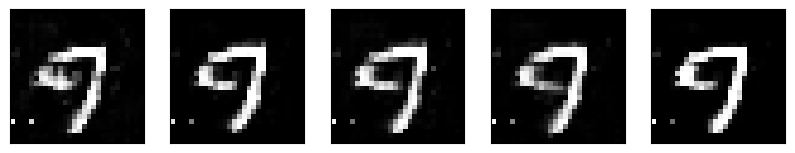

ÉPOCA 017 finalizada: Loss discriminador 0.335484 - Loss gerador 19.657403      


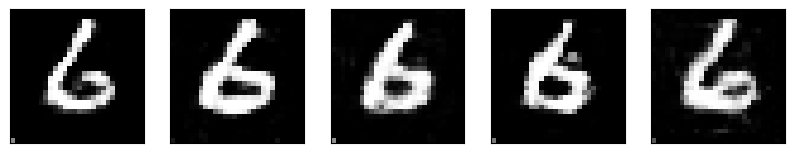

ÉPOCA 018 finalizada: Loss discriminador 0.344873 - Loss gerador 17.861837      


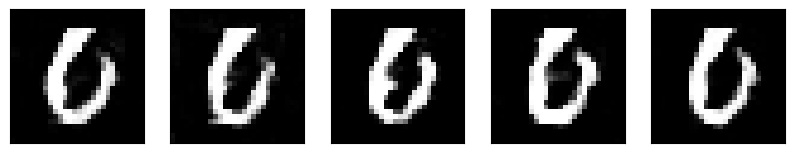

ÉPOCA 019 finalizada: Loss discriminador 0.346858 - Loss gerador 17.987177      


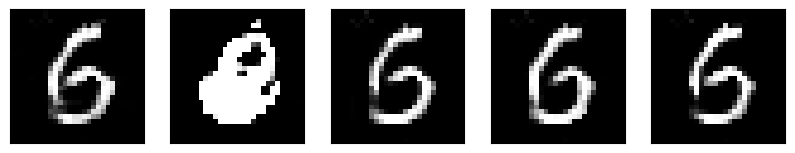

ÉPOCA 020 finalizada: Loss discriminador 0.342013 - Loss gerador 16.521962      


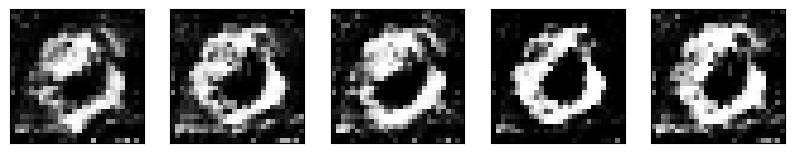

ÉPOCA 021 finalizada: Loss discriminador 0.337252 - Loss gerador 21.568471      


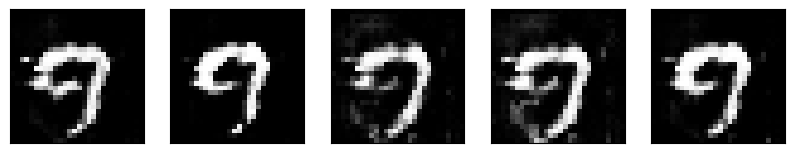

ÉPOCA 022 finalizada: Loss discriminador 0.338486 - Loss gerador 18.424087      


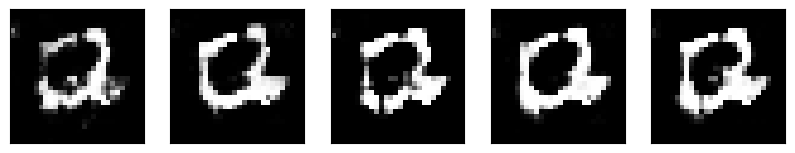

ÉPOCA 023 finalizada: Loss discriminador 0.332170 - Loss gerador 26.309327      


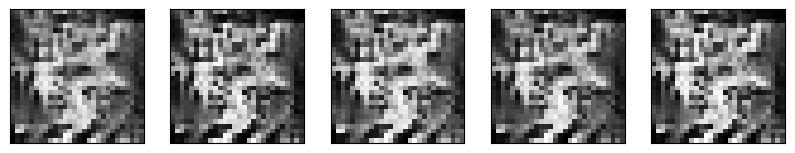

ÉPOCA 024 finalizada: Loss discriminador 0.330984 - Loss gerador 29.397274      


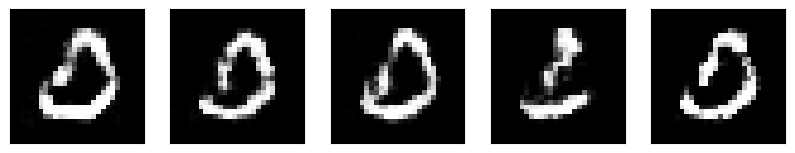

ÉPOCA 025 finalizada: Loss discriminador 0.339135 - Loss gerador 21.510606      


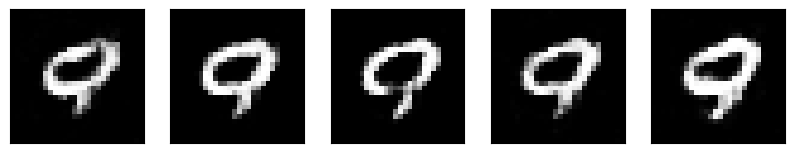

ÉPOCA 026 finalizada: Loss discriminador 0.339404 - Loss gerador 23.370040      


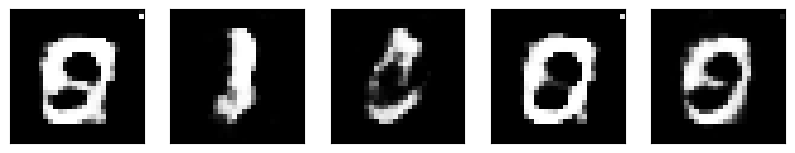

ÉPOCA 027 finalizada: Loss discriminador 0.344732 - Loss gerador 16.028180      


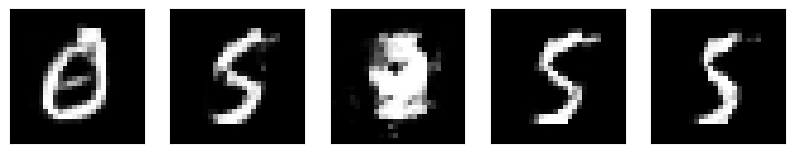

ÉPOCA 028 finalizada: Loss discriminador 0.344832 - Loss gerador 13.527218      


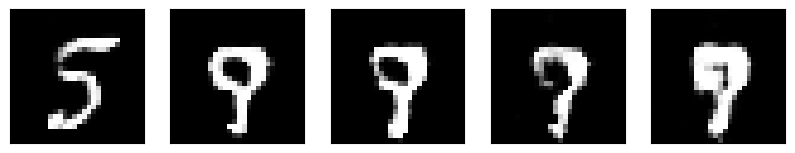

ÉPOCA 029 finalizada: Loss discriminador 0.343858 - Loss gerador 14.647137      


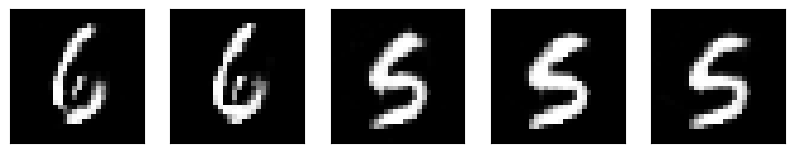

ÉPOCA 030 finalizada: Loss discriminador 0.342745 - Loss gerador 17.349719      


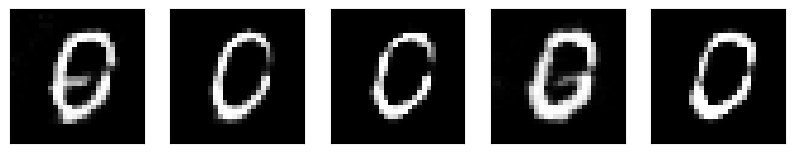

ÉPOCA 031 finalizada: Loss discriminador 0.342776 - Loss gerador 20.850497      


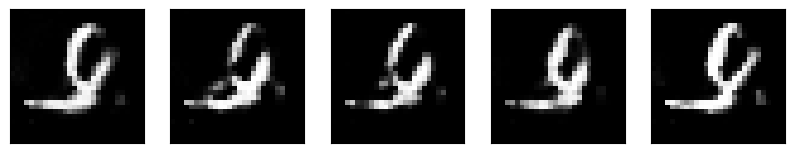

ÉPOCA 032 finalizada: Loss discriminador 0.334343 - Loss gerador 30.319747      


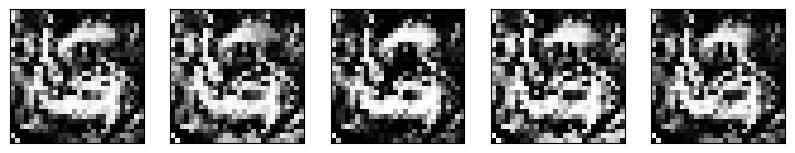

ÉPOCA 033 finalizada: Loss discriminador 0.328042 - Loss gerador 21.864037      


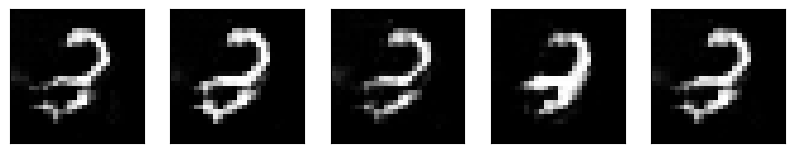

ÉPOCA 034 finalizada: Loss discriminador 0.328874 - Loss gerador 20.240037      


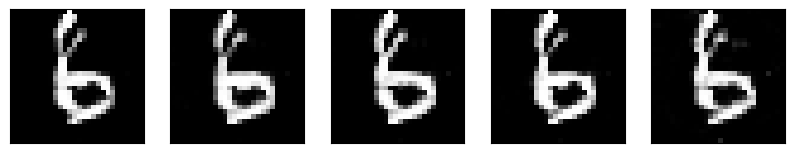

ÉPOCA 035 finalizada: Loss discriminador 0.329699 - Loss gerador 23.354593      


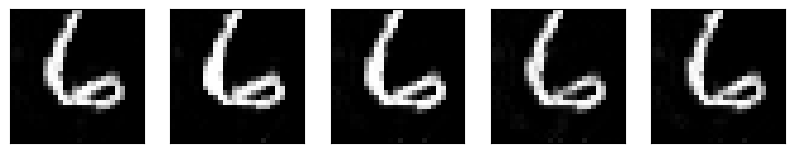

ÉPOCA 036 finalizada: Loss discriminador 0.333668 - Loss gerador 23.550716      


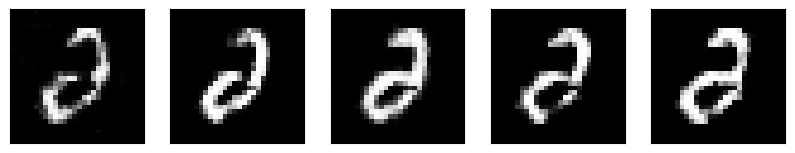

ÉPOCA 037 finalizada: Loss discriminador 0.330357 - Loss gerador 24.895567      


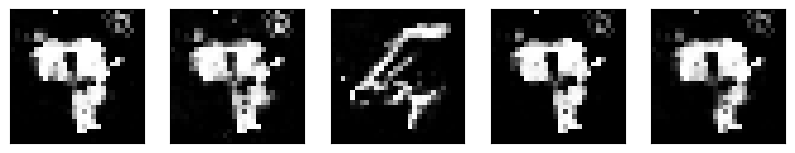

ÉPOCA 038 finalizada: Loss discriminador 0.334900 - Loss gerador 29.928248      


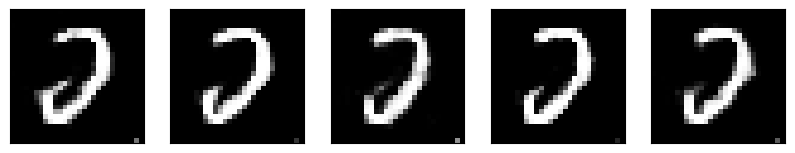

ÉPOCA 039 finalizada: Loss discriminador 0.332788 - Loss gerador 23.010255      


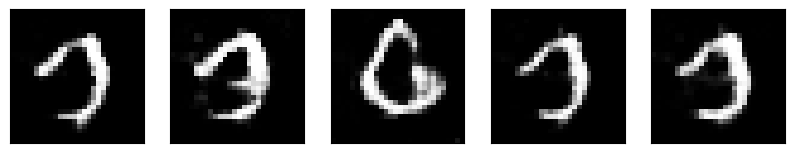

ÉPOCA 040 finalizada: Loss discriminador 0.336840 - Loss gerador 21.089425      


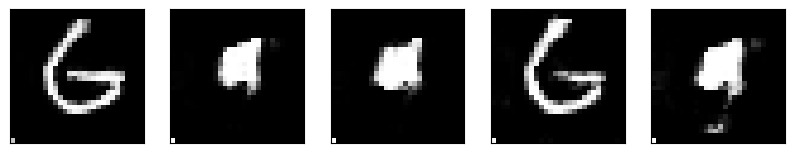

ÉPOCA 041 finalizada: Loss discriminador 0.333825 - Loss gerador 20.292307      


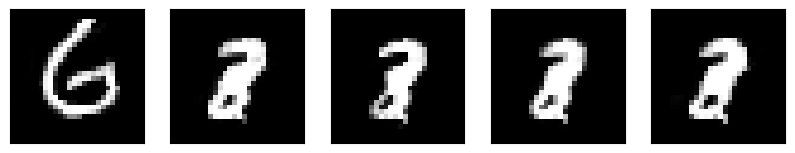

ÉPOCA 042 finalizada: Loss discriminador 0.339648 - Loss gerador 22.550318      


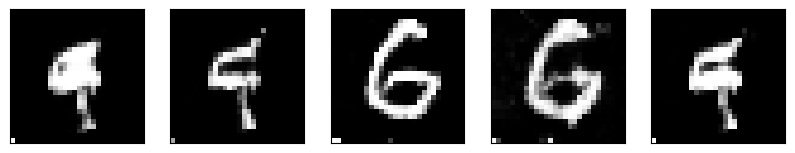

ÉPOCA 043 finalizada: Loss discriminador 0.338701 - Loss gerador 16.356301      


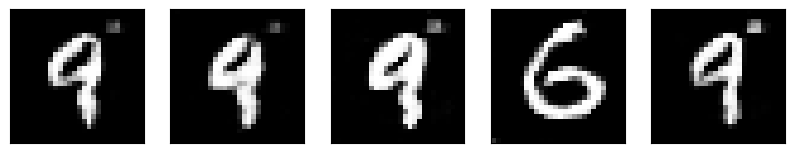

ÉPOCA 044 finalizada: Loss discriminador 0.337853 - Loss gerador 19.229064      


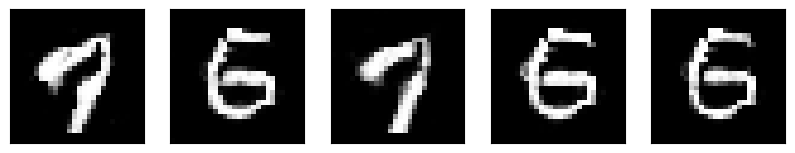

ÉPOCA 045 finalizada: Loss discriminador 0.342692 - Loss gerador 22.502487      


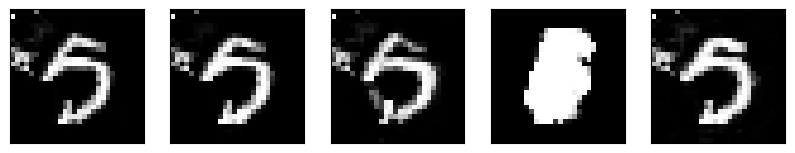

ÉPOCA 046 finalizada: Loss discriminador 0.335196 - Loss gerador 24.668693      


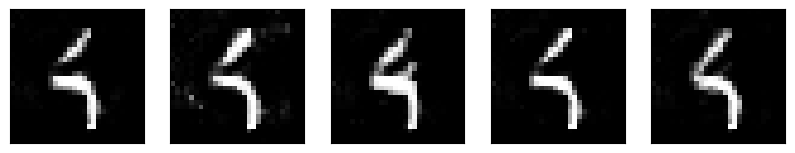

ÉPOCA 047 finalizada: Loss discriminador 0.335195 - Loss gerador 24.607361      


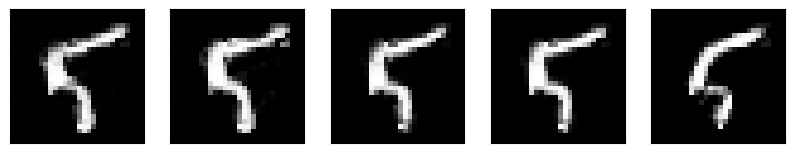

ÉPOCA 048 finalizada: Loss discriminador 0.335735 - Loss gerador 19.596121      


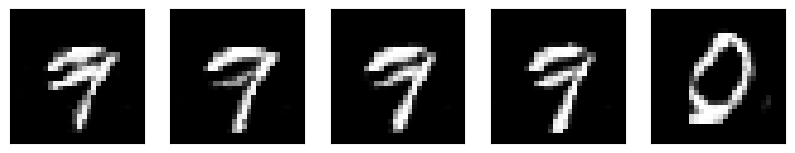

ÉPOCA 049 finalizada: Loss discriminador 0.339266 - Loss gerador 21.496403      


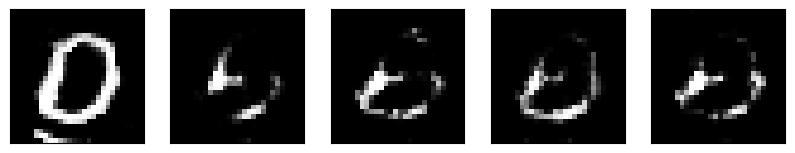

ÉPOCA 050 finalizada: Loss discriminador 0.339846 - Loss gerador 30.942164      3
Novo melhor G salvo em época 50 com loss 30.942164
Novo melhor D salvo em época 50 com loss 0.339846


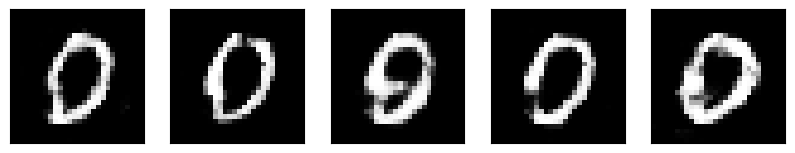

ÉPOCA 051 finalizada: Loss discriminador 0.337319 - Loss gerador 17.640685      
Novo melhor G salvo em época 51 com loss 17.640685
Novo melhor D salvo em época 51 com loss 0.337319


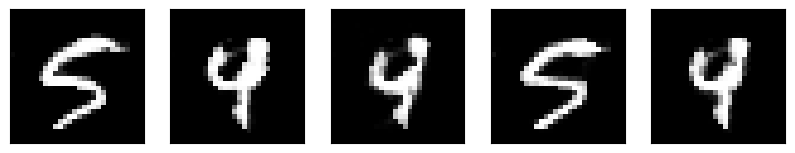

ÉPOCA 052 finalizada: Loss discriminador 0.332994 - Loss gerador 18.591046      
Novo melhor D salvo em época 52 com loss 0.332994


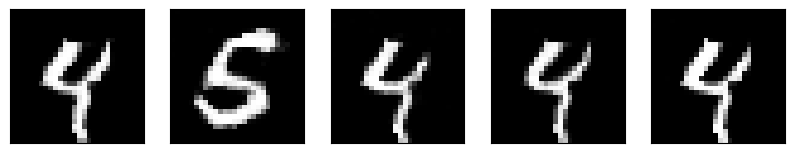

ÉPOCA 053 finalizada: Loss discriminador 0.334859 - Loss gerador 20.352435      


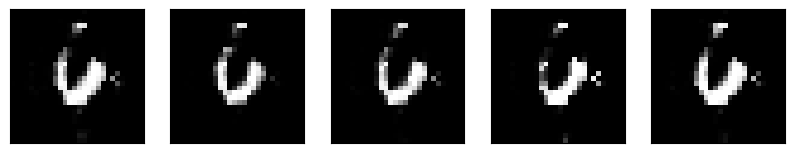

ÉPOCA 054 finalizada: Loss discriminador 0.335854 - Loss gerador 21.412250      


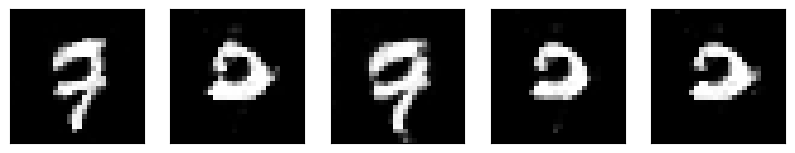

ÉPOCA 055 finalizada: Loss discriminador 0.337286 - Loss gerador 20.617979      


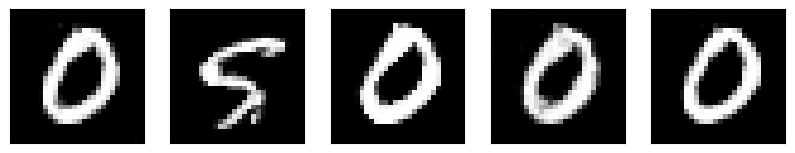

ÉPOCA 056 finalizada: Loss discriminador 0.343182 - Loss gerador 24.568840      


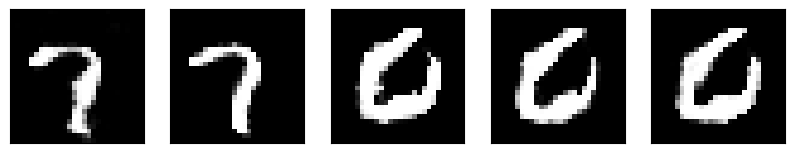

ÉPOCA 057 finalizada: Loss discriminador 0.339463 - Loss gerador 18.633301      


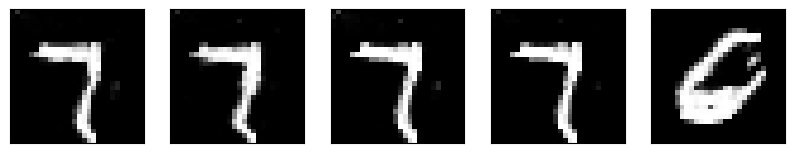

ÉPOCA 058 finalizada: Loss discriminador 0.335433 - Loss gerador 19.902606      


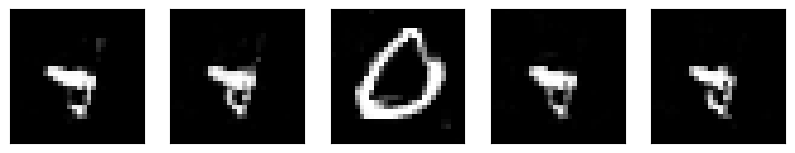

ÉPOCA 059 finalizada: Loss discriminador 0.336363 - Loss gerador 23.181069      


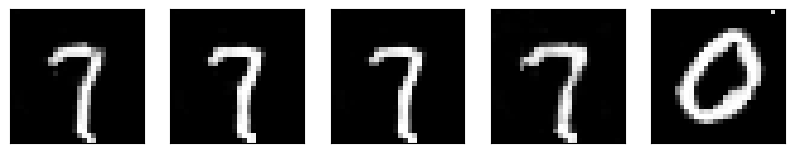

ÉPOCA 060 finalizada: Loss discriminador 0.335222 - Loss gerador 19.586038      


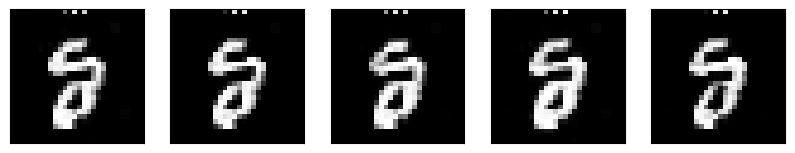

ÉPOCA 061 finalizada: Loss discriminador 0.337378 - Loss gerador 25.023034      


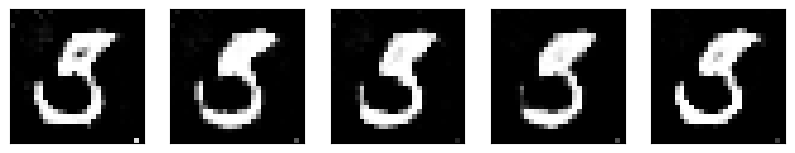

ÉPOCA 062 finalizada: Loss discriminador 0.333792 - Loss gerador 29.408249      


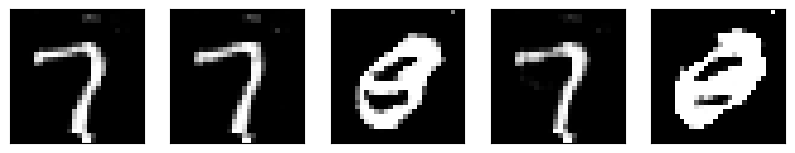

ÉPOCA 063 finalizada: Loss discriminador 0.341430 - Loss gerador 21.400615      


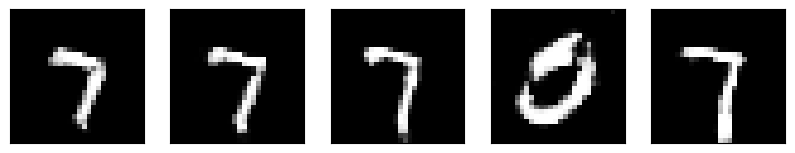

ÉPOCA 064 finalizada: Loss discriminador 0.338125 - Loss gerador 18.193596      


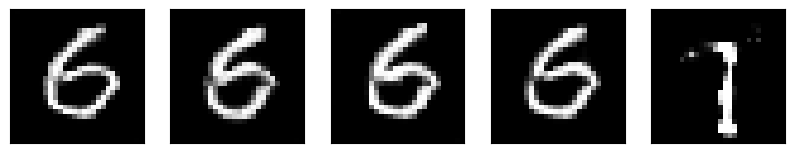

ÉPOCA 065 finalizada: Loss discriminador 0.341268 - Loss gerador 17.698327      


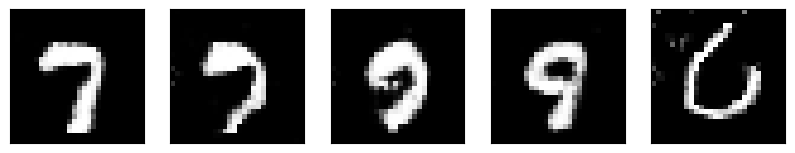

ÉPOCA 066 finalizada: Loss discriminador 0.340049 - Loss gerador 19.519615      


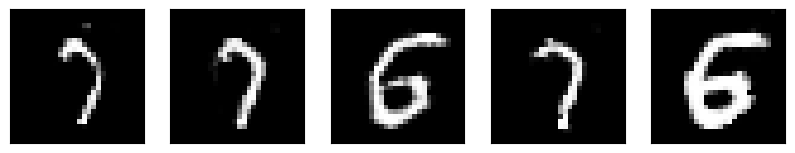

ÉPOCA 067 finalizada: Loss discriminador 0.340081 - Loss gerador 21.039249      


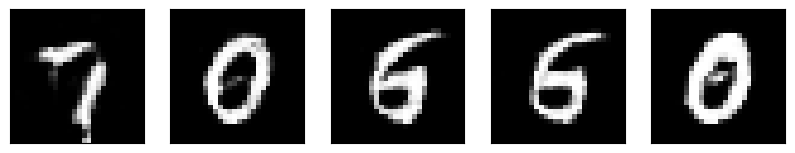

ÉPOCA 068 finalizada: Loss discriminador 0.333730 - Loss gerador 17.583894      
Novo melhor G salvo em época 68 com loss 17.583894


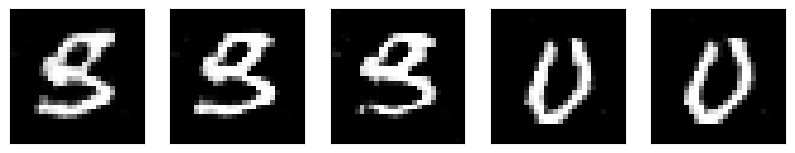

ÉPOCA 069 finalizada: Loss discriminador 0.340571 - Loss gerador 23.047251      


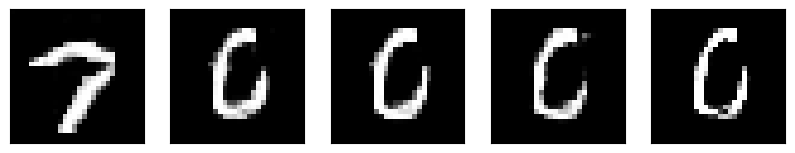

ÉPOCA 070 finalizada: Loss discriminador 0.335441 - Loss gerador 20.530322      


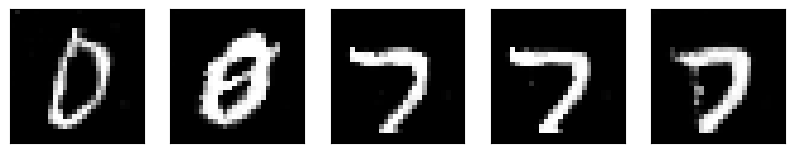

ÉPOCA 071 finalizada: Loss discriminador 0.337768 - Loss gerador 18.012708      


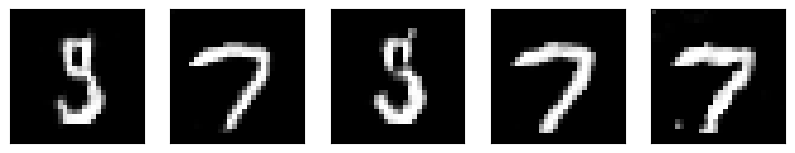

ÉPOCA 072 finalizada: Loss discriminador 0.335672 - Loss gerador 26.218127      


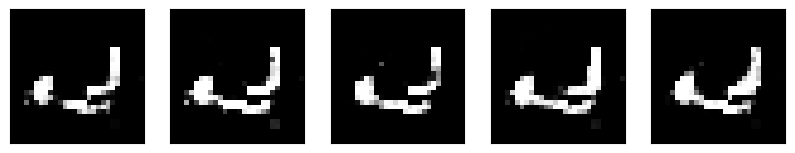

ÉPOCA 073 finalizada: Loss discriminador 0.335169 - Loss gerador 27.374323      


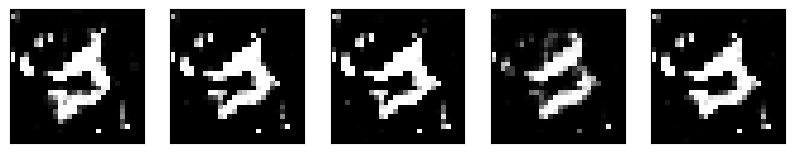

ÉPOCA 074 finalizada: Loss discriminador 0.330137 - Loss gerador 55.954999      7
Novo melhor D salvo em época 74 com loss 0.330137


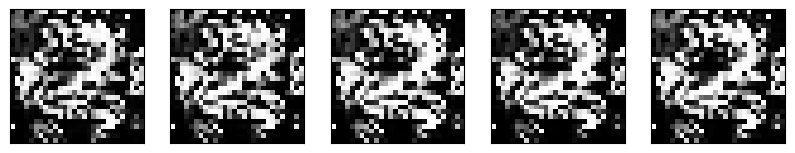

ÉPOCA 075 finalizada: Loss discriminador 0.326728 - Loss gerador 53.666994      9
Novo melhor D salvo em época 75 com loss 0.326728


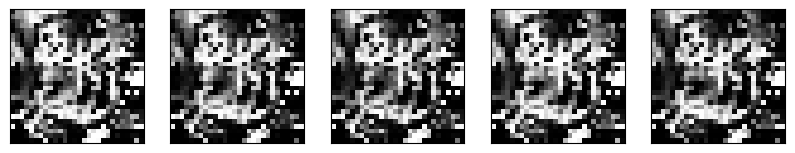

ÉPOCA 076 finalizada: Loss discriminador 0.326905 - Loss gerador 50.503406      


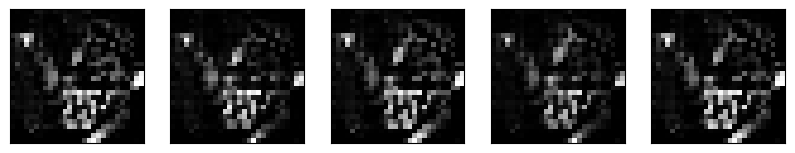

ÉPOCA 077 finalizada: Loss discriminador 0.327224 - Loss gerador 61.767512      1


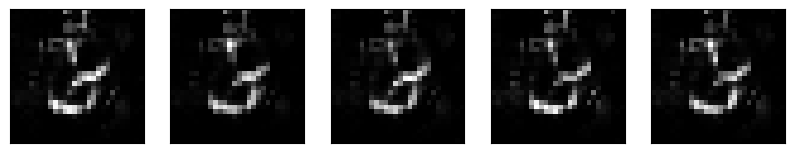

ÉPOCA 078 finalizada: Loss discriminador 0.325299 - Loss gerador 37.673759      
Novo melhor D salvo em época 78 com loss 0.325299


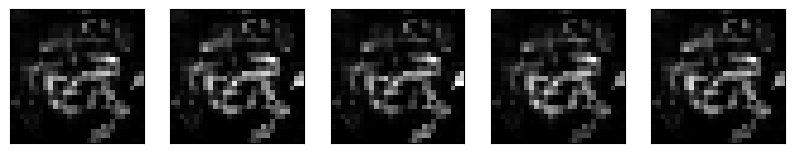

ÉPOCA 079 finalizada: Loss discriminador 0.328584 - Loss gerador 42.341472      0


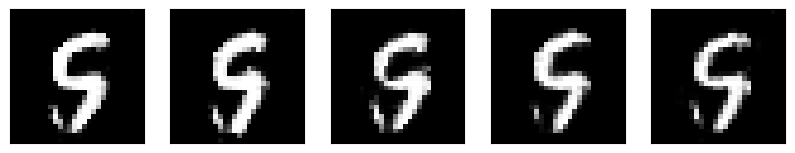

ÉPOCA 080 finalizada: Loss discriminador 0.326838 - Loss gerador 29.290736      


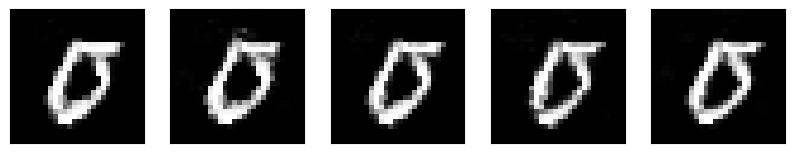

ÉPOCA 081 finalizada: Loss discriminador 0.327392 - Loss gerador 29.180909      


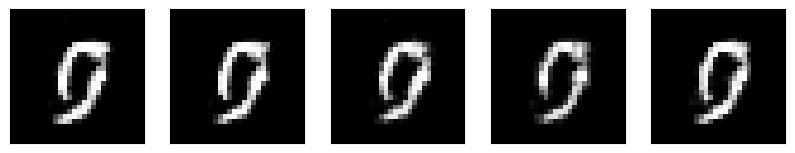

ÉPOCA 082 finalizada: Loss discriminador 0.330211 - Loss gerador 31.264879      


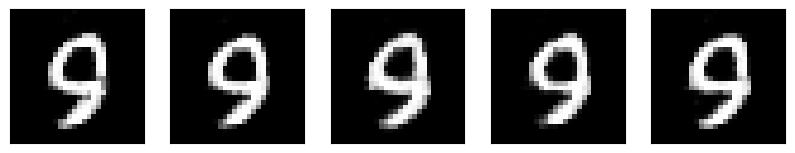

ÉPOCA 083 finalizada: Loss discriminador 0.326793 - Loss gerador 30.929509      


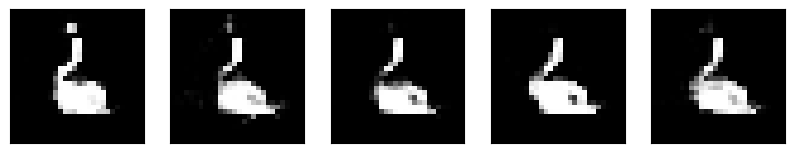

ÉPOCA 084 finalizada: Loss discriminador 0.330499 - Loss gerador 45.795036      6


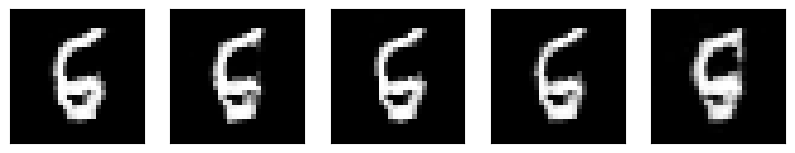

ÉPOCA 085 finalizada: Loss discriminador 0.329334 - Loss gerador 35.909083      


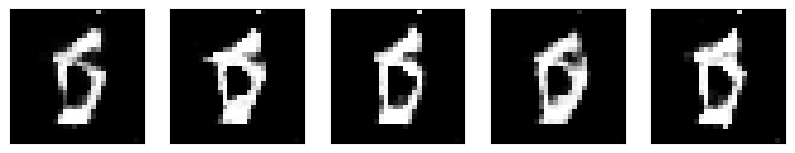

ÉPOCA 086 finalizada: Loss discriminador 0.331025 - Loss gerador 42.482748      9


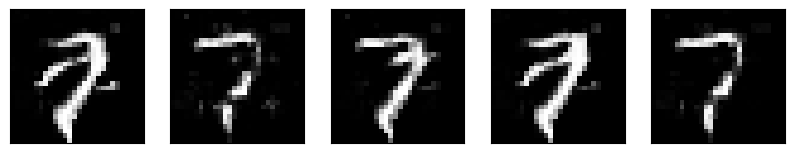

ÉPOCA 087 finalizada: Loss discriminador 0.329664 - Loss gerador 37.123326      


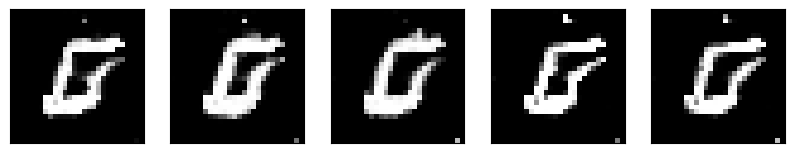

ÉPOCA 088 finalizada: Loss discriminador 0.327463 - Loss gerador 47.371551      


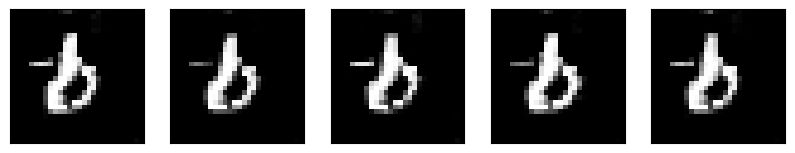

ÉPOCA 089 finalizada: Loss discriminador 0.326614 - Loss gerador 83.477993      5


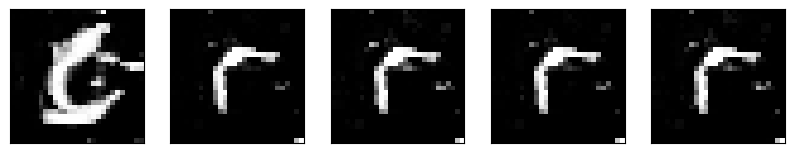

ÉPOCA 090 finalizada: Loss discriminador 0.327086 - Loss gerador 50.330847      7


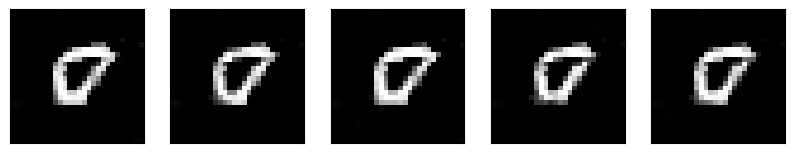

ÉPOCA 091 finalizada: Loss discriminador 0.326357 - Loss gerador 36.768882      


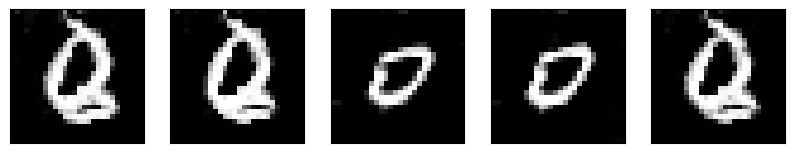

ÉPOCA 092 finalizada: Loss discriminador 0.339339 - Loss gerador 36.051471      4


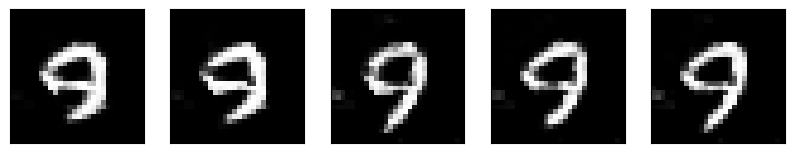

ÉPOCA 093 finalizada: Loss discriminador 0.329271 - Loss gerador 24.063041      


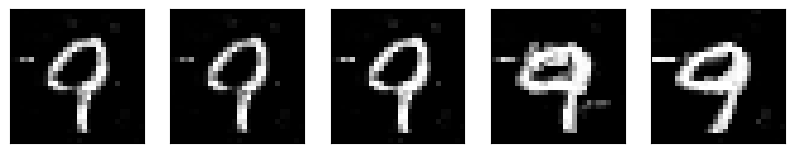

ÉPOCA 094 finalizada: Loss discriminador 0.329015 - Loss gerador 31.899607      


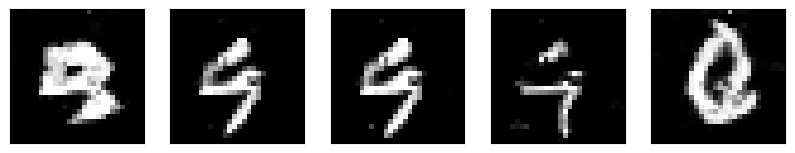

ÉPOCA 095 finalizada: Loss discriminador 0.326768 - Loss gerador 61.160838      3


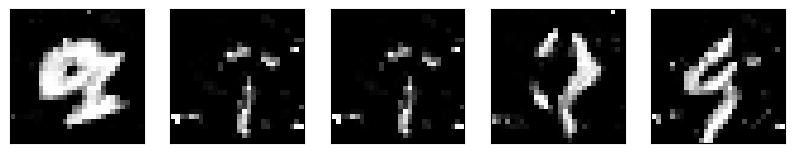

ÉPOCA 096 finalizada: Loss discriminador 0.328465 - Loss gerador 51.152862      5


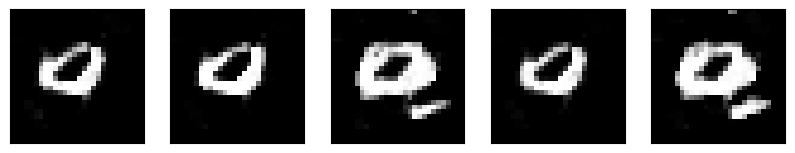

ÉPOCA 097 finalizada: Loss discriminador 0.326609 - Loss gerador 29.834466      


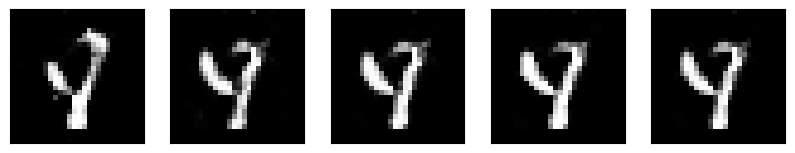

ÉPOCA 098 finalizada: Loss discriminador 0.326649 - Loss gerador 38.265368      


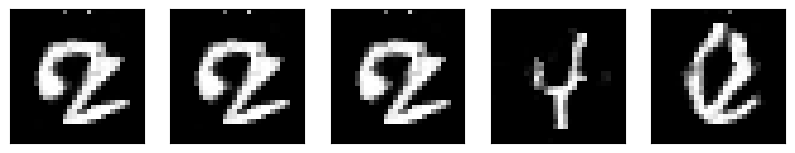

ÉPOCA 099 finalizada: Loss discriminador 0.346237 - Loss gerador 41.397251      3


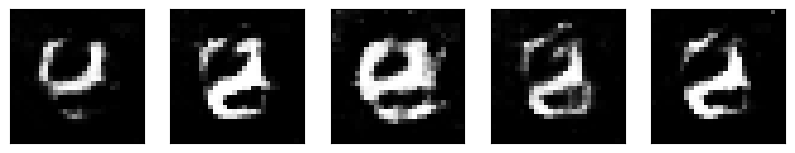

ÉPOCA 100 finalizada: Loss discriminador 0.357407 - Loss gerador 31.875293      


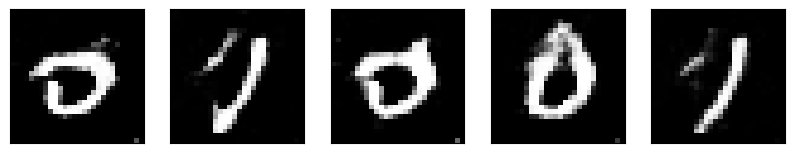

ÉPOCA 101 finalizada: Loss discriminador 0.339293 - Loss gerador 19.602471      


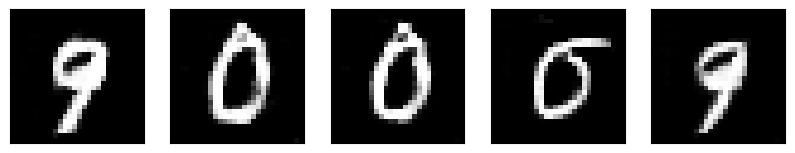

ÉPOCA 102 finalizada: Loss discriminador 0.350294 - Loss gerador 26.118497      3


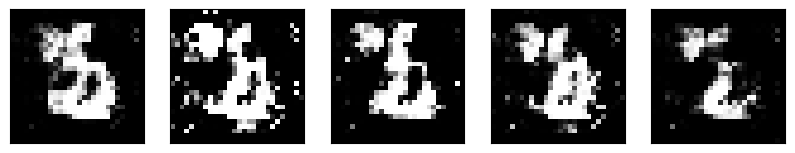

ÉPOCA 103 finalizada: Loss discriminador 0.353636 - Loss gerador 26.231161      


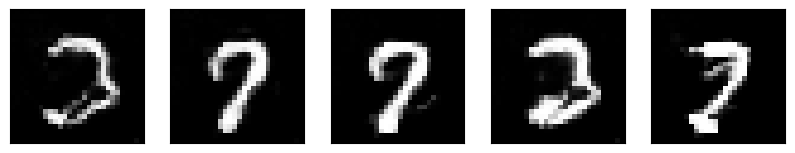

ÉPOCA 104 finalizada: Loss discriminador 0.342948 - Loss gerador 18.745936      


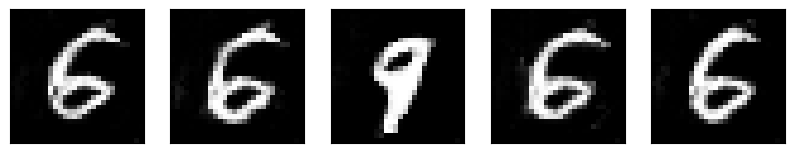

ÉPOCA 105 finalizada: Loss discriminador 0.341108 - Loss gerador 14.007130      
Novo melhor G salvo em época 105 com loss 14.007130


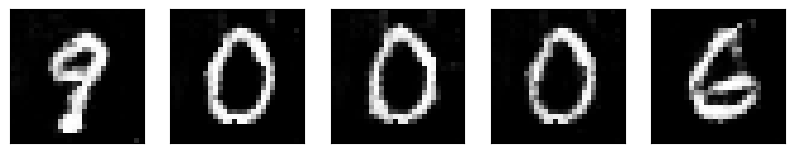

ÉPOCA 106 finalizada: Loss discriminador 0.339753 - Loss gerador 14.939297      


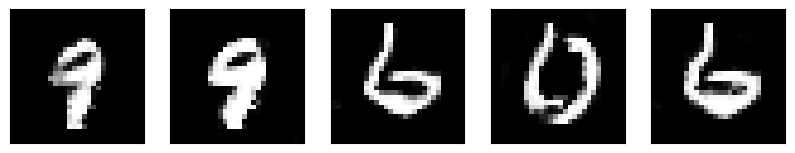

ÉPOCA 107 finalizada: Loss discriminador 0.338787 - Loss gerador 14.232022      


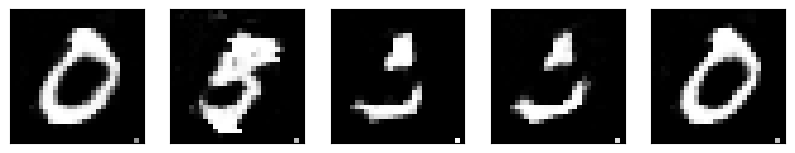

ÉPOCA 108 finalizada: Loss discriminador 0.342932 - Loss gerador 19.167949      


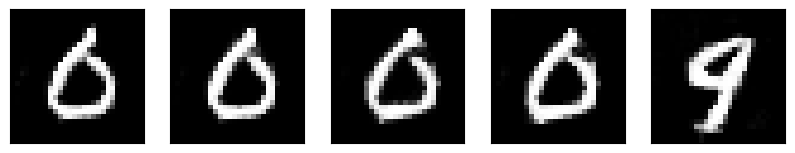

ÉPOCA 109 finalizada: Loss discriminador 0.336328 - Loss gerador 16.551530      


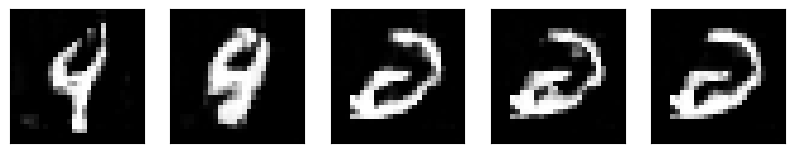

ÉPOCA 110 finalizada: Loss discriminador 0.339750 - Loss gerador 22.951803      


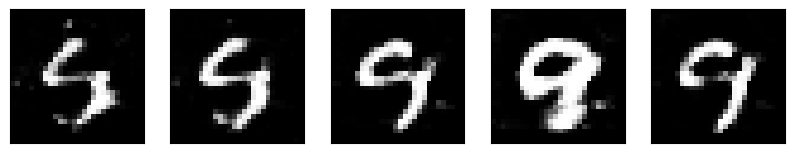

ÉPOCA 111 finalizada: Loss discriminador 0.338110 - Loss gerador 20.286125      


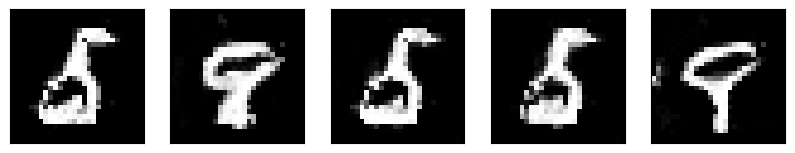

ÉPOCA 112 finalizada: Loss discriminador 0.338282 - Loss gerador 18.693460      


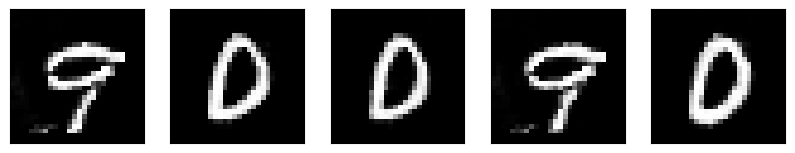

ÉPOCA 113 finalizada: Loss discriminador 0.337640 - Loss gerador 18.464471      


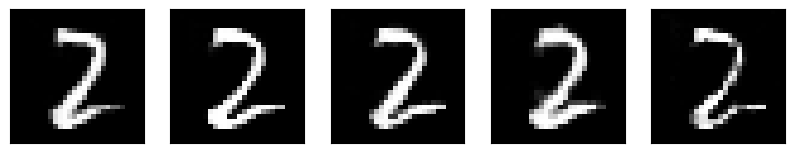

ÉPOCA 114 finalizada: Loss discriminador 0.345526 - Loss gerador 21.900963      


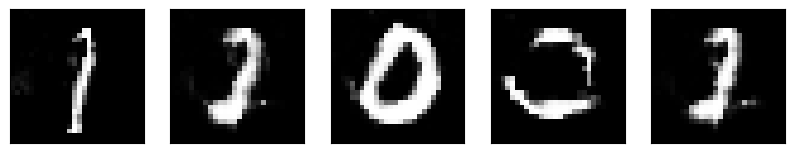

ÉPOCA 115 finalizada: Loss discriminador 0.338689 - Loss gerador 18.119944      


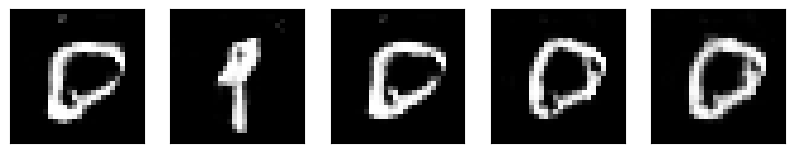

ÉPOCA 116 finalizada: Loss discriminador 0.332704 - Loss gerador 22.272542      


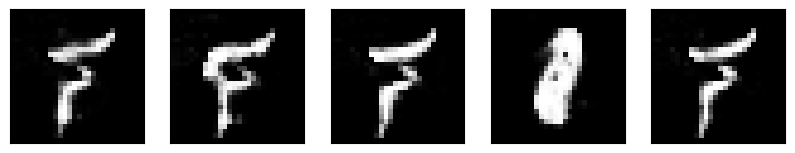

ÉPOCA 117 finalizada: Loss discriminador 0.333532 - Loss gerador 17.296677      


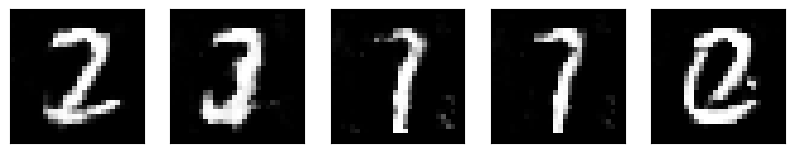

ÉPOCA 118 finalizada: Loss discriminador 0.335747 - Loss gerador 17.229831      


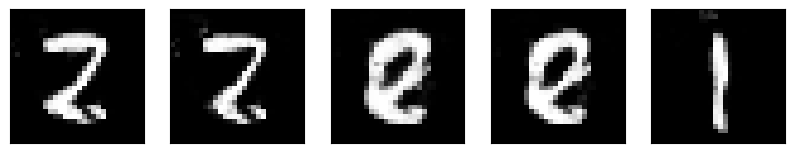

ÉPOCA 119 finalizada: Loss discriminador 0.342221 - Loss gerador 17.505787      


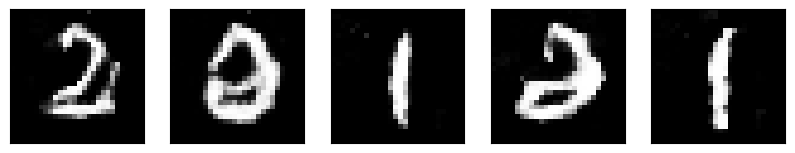

ÉPOCA 120 finalizada: Loss discriminador 0.337765 - Loss gerador 17.941260      


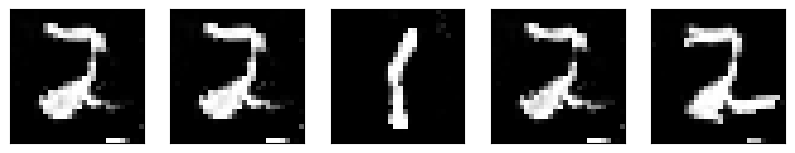

ÉPOCA 121 finalizada: Loss discriminador 0.336786 - Loss gerador 15.643769      


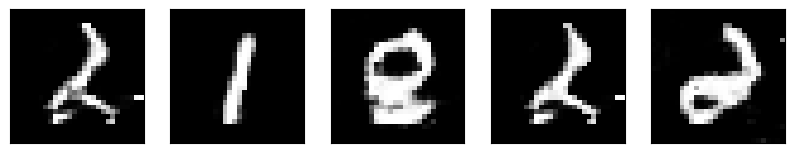

ÉPOCA 122 finalizada: Loss discriminador 0.339753 - Loss gerador 20.008070      


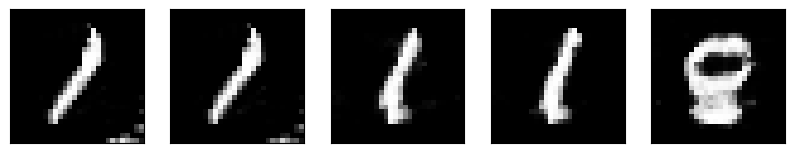

ÉPOCA 123 finalizada: Loss discriminador 0.335552 - Loss gerador 21.897745      


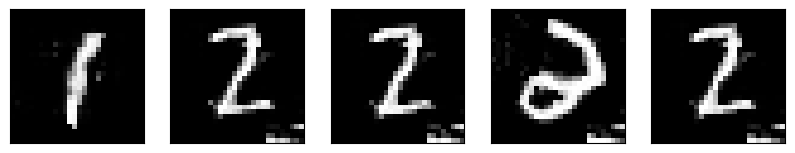

ÉPOCA 124 finalizada: Loss discriminador 0.336118 - Loss gerador 19.972658      


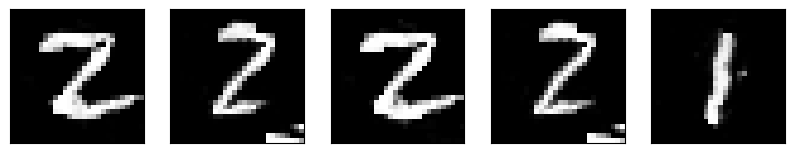

ÉPOCA 125 finalizada: Loss discriminador 0.335557 - Loss gerador 19.376648      


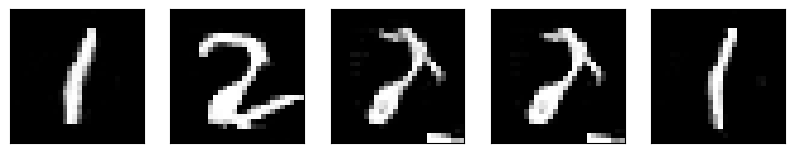

ÉPOCA 126 finalizada: Loss discriminador 0.341876 - Loss gerador 24.897864      7


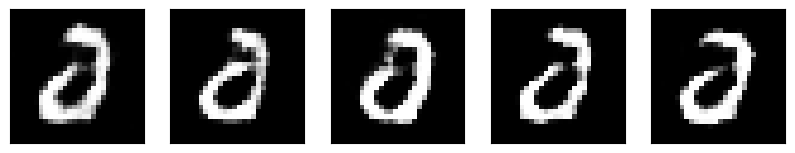

ÉPOCA 127 finalizada: Loss discriminador 0.351533 - Loss gerador 28.793895      


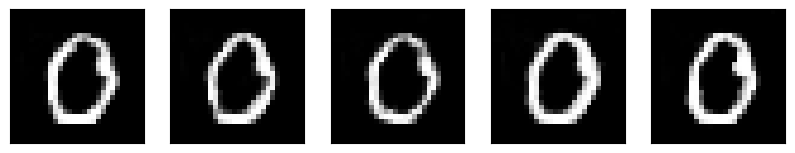

ÉPOCA 128 finalizada: Loss discriminador 0.336552 - Loss gerador 18.501639      


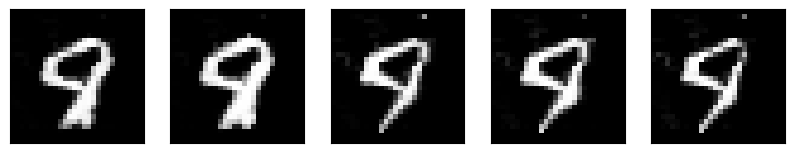

ÉPOCA 129 finalizada: Loss discriminador 0.327682 - Loss gerador 16.896890      


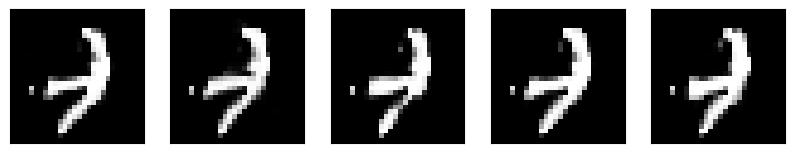

ÉPOCA 130 finalizada: Loss discriminador 0.337307 - Loss gerador 42.600745      4


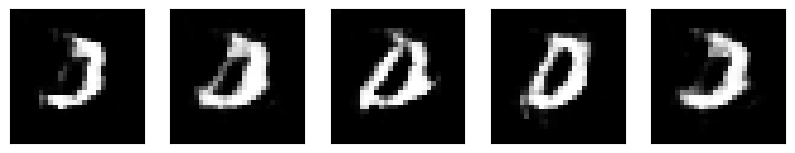

ÉPOCA 131 finalizada: Loss discriminador 0.334317 - Loss gerador 18.904710      


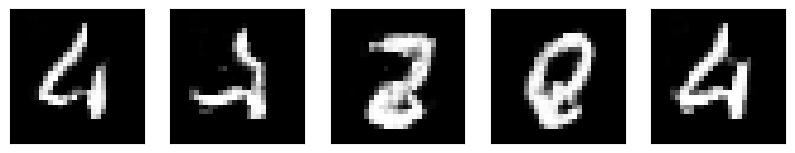

ÉPOCA 132 finalizada: Loss discriminador 0.337506 - Loss gerador 17.324553      


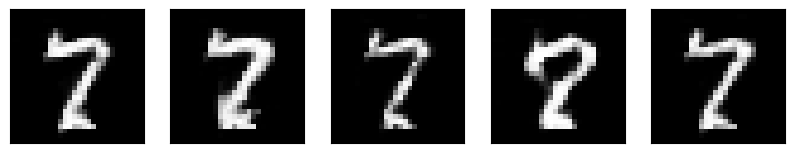

ÉPOCA 133 finalizada: Loss discriminador 0.340522 - Loss gerador 18.157699      


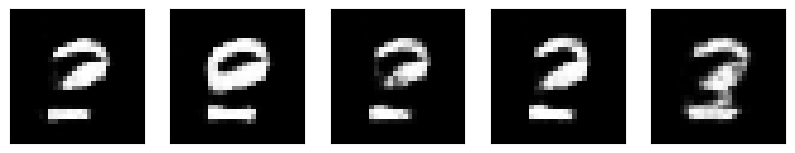

ÉPOCA 134 finalizada: Loss discriminador 0.335923 - Loss gerador 17.884794      


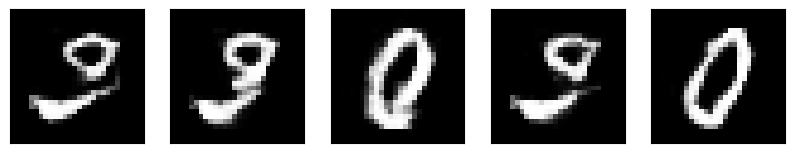

ÉPOCA 135 finalizada: Loss discriminador 0.336360 - Loss gerador 16.345179      


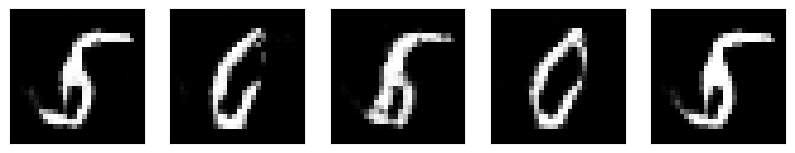

ÉPOCA 136 finalizada: Loss discriminador 0.361748 - Loss gerador 19.562051      


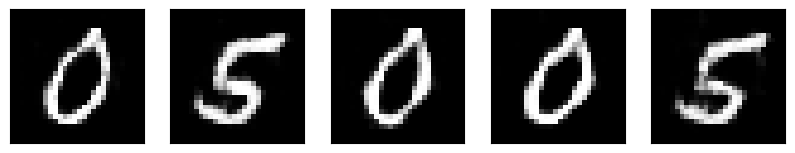

ÉPOCA 137 finalizada: Loss discriminador 0.362219 - Loss gerador 17.381306      


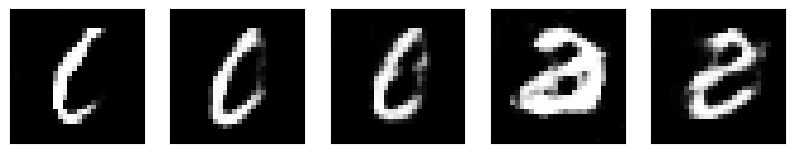

ÉPOCA 138 finalizada: Loss discriminador 0.354417 - Loss gerador 21.245042      


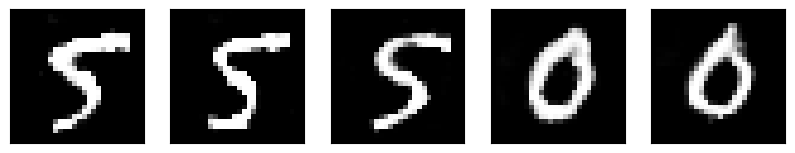

ÉPOCA 139 finalizada: Loss discriminador 0.352865 - Loss gerador 14.037491      


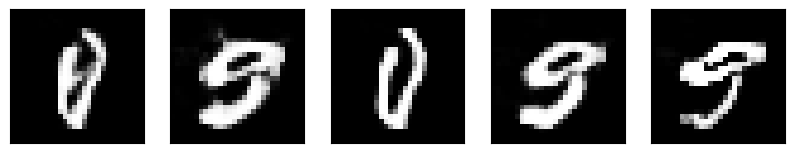

ÉPOCA 140 finalizada: Loss discriminador 0.371640 - Loss gerador 15.085596      


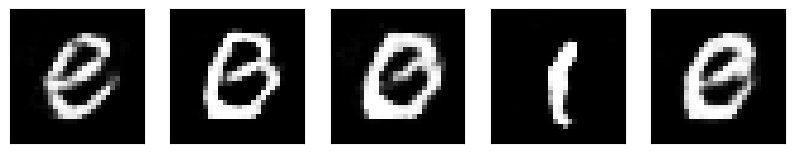

ÉPOCA 141 finalizada: Loss discriminador 0.365785 - Loss gerador 11.695903      
Novo melhor G salvo em época 141 com loss 11.695903


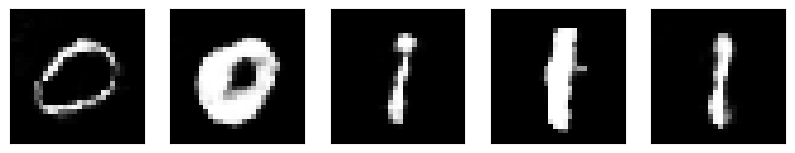

ÉPOCA 142 finalizada: Loss discriminador 0.359953 - Loss gerador 14.378244      


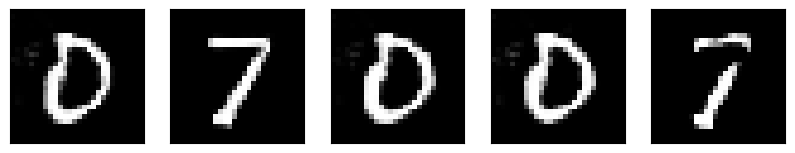

ÉPOCA 143 finalizada: Loss discriminador 0.357550 - Loss gerador 17.794200      


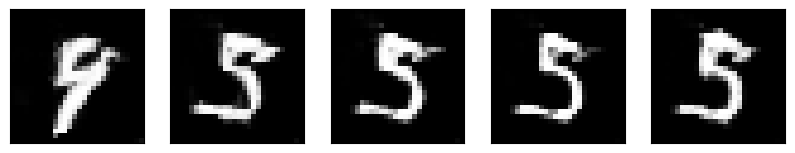

ÉPOCA 144 finalizada: Loss discriminador 0.344042 - Loss gerador 21.833064      


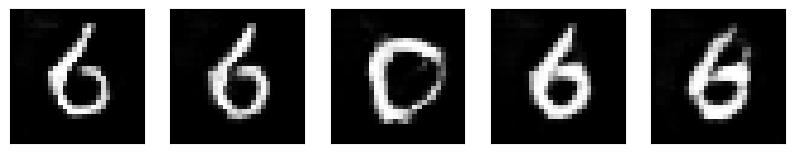

ÉPOCA 145 finalizada: Loss discriminador 0.341961 - Loss gerador 14.831129      


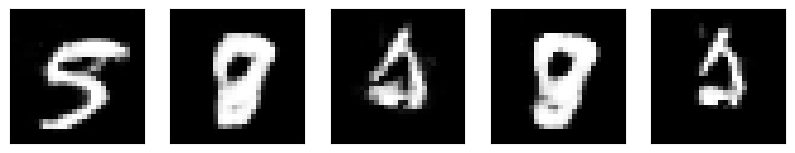

ÉPOCA 146 finalizada: Loss discriminador 0.338307 - Loss gerador 12.909090      


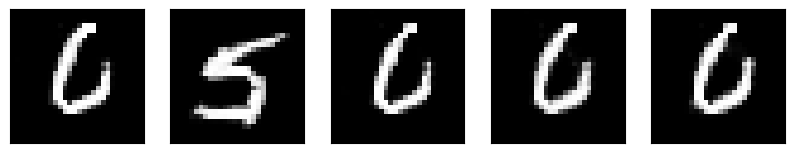

ÉPOCA 147 finalizada: Loss discriminador 0.346401 - Loss gerador 15.140759      


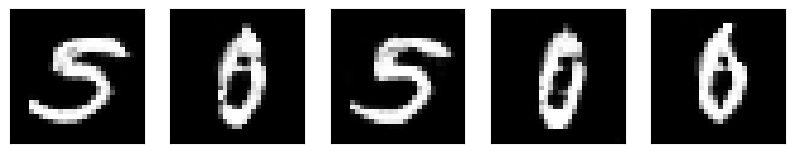

ÉPOCA 148 finalizada: Loss discriminador 0.342583 - Loss gerador 13.868973      


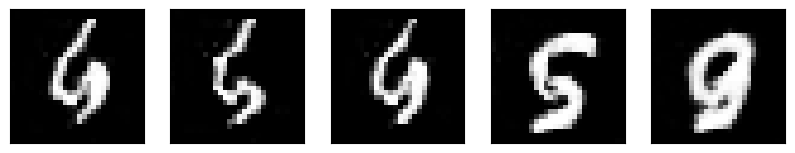

ÉPOCA 149 finalizada: Loss discriminador 0.340232 - Loss gerador 17.809246      


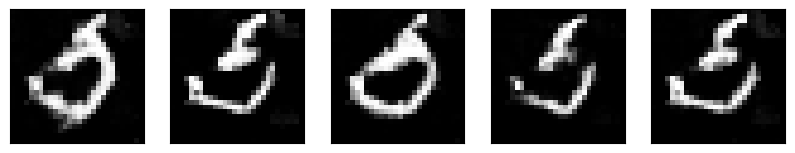

ÉPOCA 150 finalizada: Loss discriminador 0.341781 - Loss gerador 24.005597      


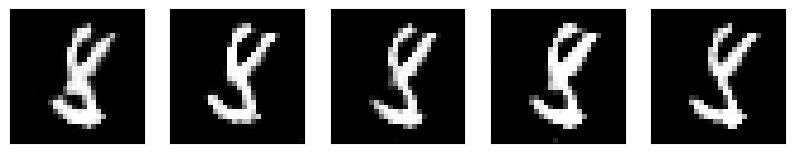

ÉPOCA 151 finalizada: Loss discriminador 0.330952 - Loss gerador 21.898908      


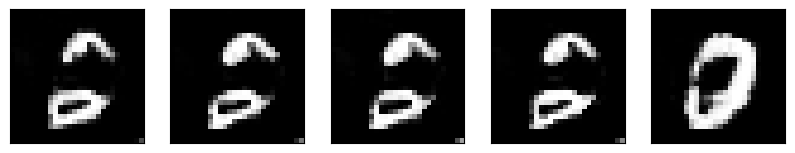

ÉPOCA 152 finalizada: Loss discriminador 0.329616 - Loss gerador 35.663412      


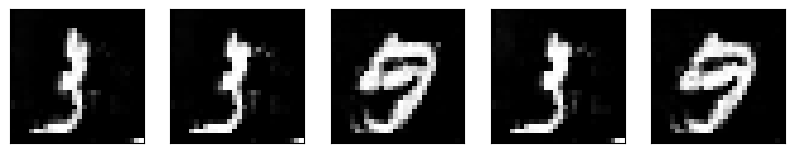

ÉPOCA 153 finalizada: Loss discriminador 0.328056 - Loss gerador 31.225255      


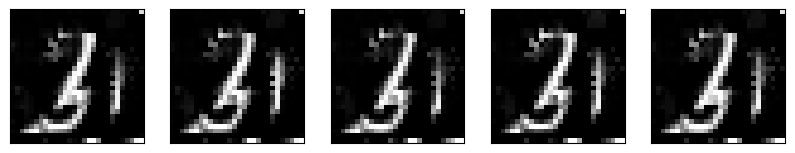

ÉPOCA 154 finalizada: Loss discriminador 0.332553 - Loss gerador 27.276812      


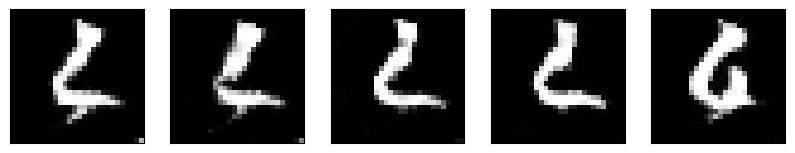

ÉPOCA 155 finalizada: Loss discriminador 0.332227 - Loss gerador 25.225820      


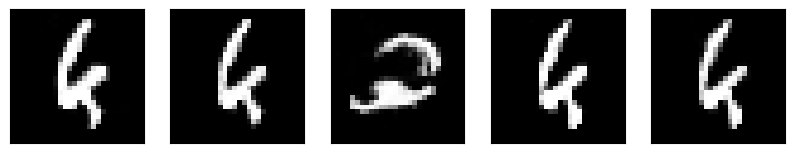

ÉPOCA 156 finalizada: Loss discriminador 0.339208 - Loss gerador 19.055819      


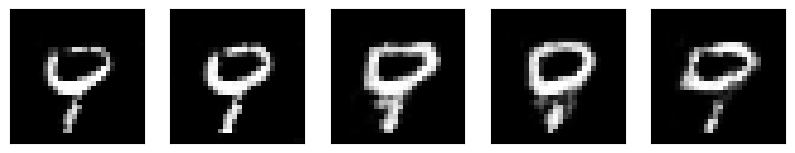

ÉPOCA 157 finalizada: Loss discriminador 0.335740 - Loss gerador 28.511046      


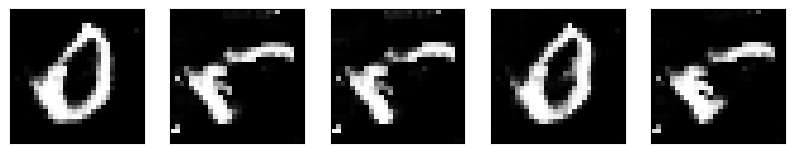

ÉPOCA 158 finalizada: Loss discriminador 0.333972 - Loss gerador 20.999740      


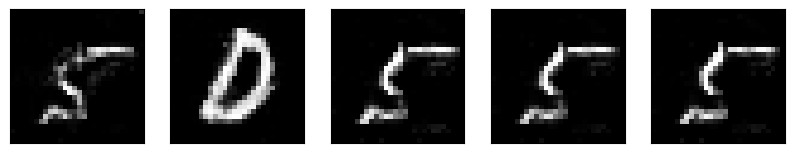

ÉPOCA 159 finalizada: Loss discriminador 0.330843 - Loss gerador 22.986891      


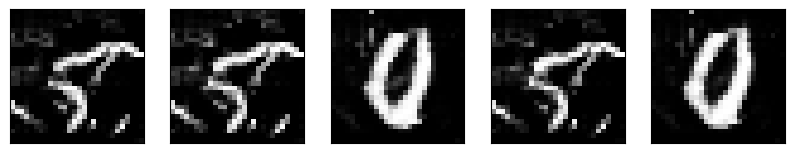

ÉPOCA 160 finalizada: Loss discriminador 0.339682 - Loss gerador 26.938227      


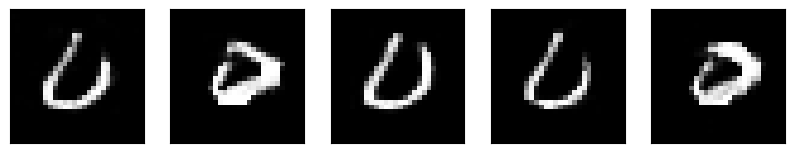

ÉPOCA 161 finalizada: Loss discriminador 0.340032 - Loss gerador 19.494244      


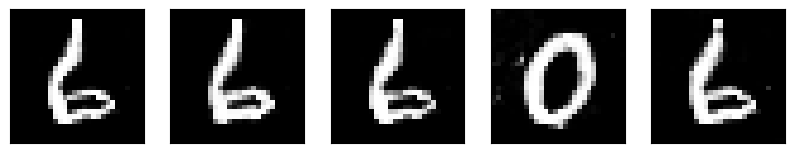

ÉPOCA 162 finalizada: Loss discriminador 0.341153 - Loss gerador 22.546014      


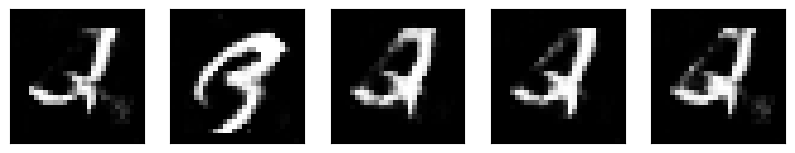

ÉPOCA 163 finalizada: Loss discriminador 0.339428 - Loss gerador 26.839717      


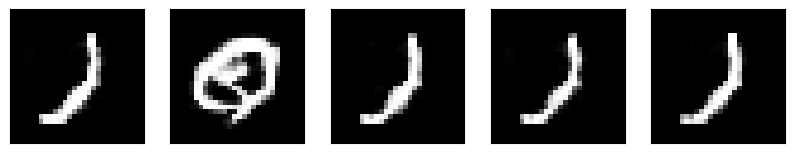

ÉPOCA 164 finalizada: Loss discriminador 0.333749 - Loss gerador 22.702198      


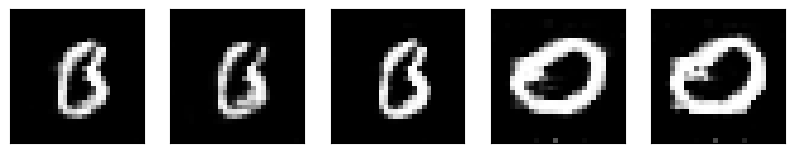

ÉPOCA 165 finalizada: Loss discriminador 0.334160 - Loss gerador 16.408221      


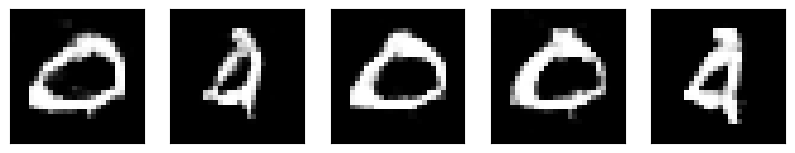

ÉPOCA 166 finalizada: Loss discriminador 0.337456 - Loss gerador 15.222720      


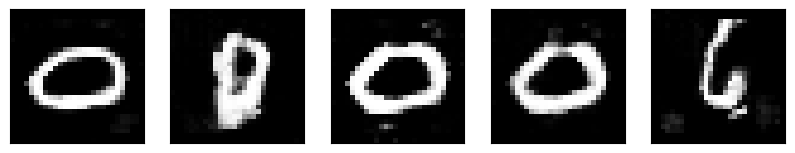

ÉPOCA 167 finalizada: Loss discriminador 0.339380 - Loss gerador 16.697188      


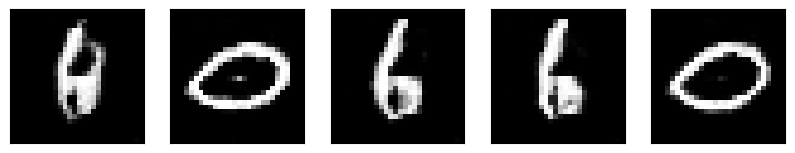

ÉPOCA 168 finalizada: Loss discriminador 0.343596 - Loss gerador 19.613615      


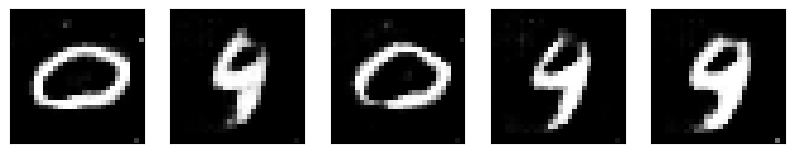

ÉPOCA 169 finalizada: Loss discriminador 0.337517 - Loss gerador 15.980011      


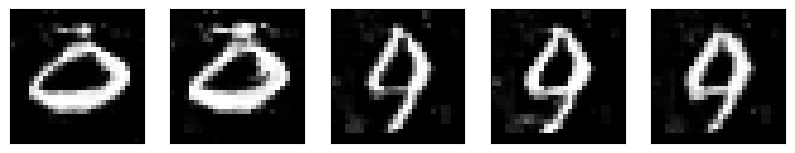

ÉPOCA 170 finalizada: Loss discriminador 0.355275 - Loss gerador 28.541274      0


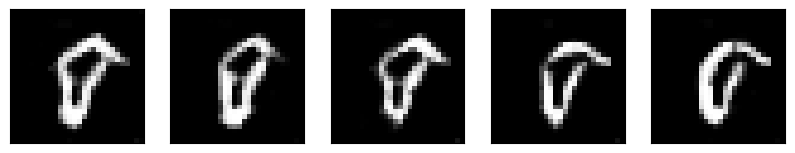

ÉPOCA 171 finalizada: Loss discriminador 0.329313 - Loss gerador 24.896702      


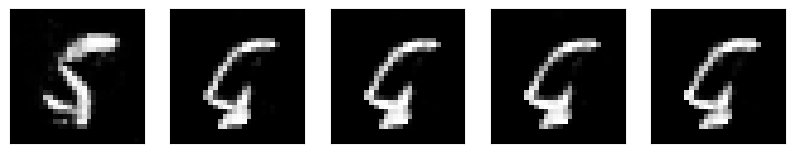

ÉPOCA 172 finalizada: Loss discriminador 0.328137 - Loss gerador 30.634762      


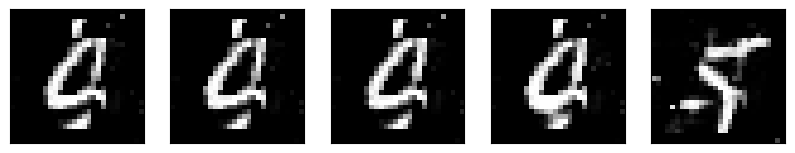

ÉPOCA 173 finalizada: Loss discriminador 0.330807 - Loss gerador 25.574381      


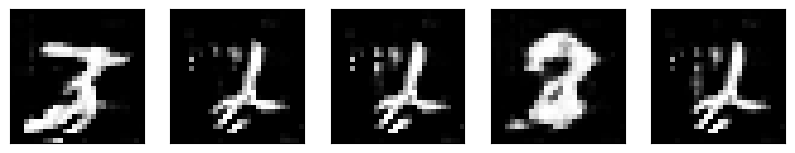

ÉPOCA 174 finalizada: Loss discriminador 0.329447 - Loss gerador 37.631332      


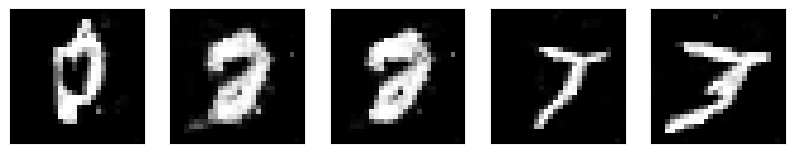

ÉPOCA 175 finalizada: Loss discriminador 0.332059 - Loss gerador 37.472530      


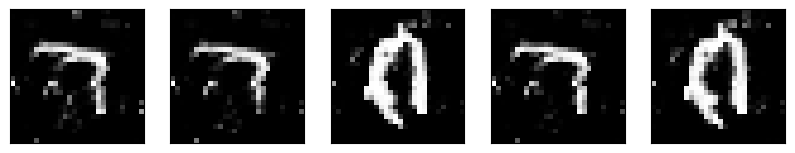

ÉPOCA 176 finalizada: Loss discriminador 0.329819 - Loss gerador 33.288626      


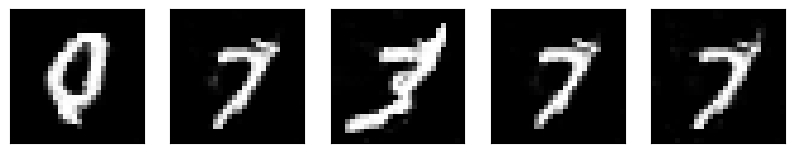

ÉPOCA 177 finalizada: Loss discriminador 0.328796 - Loss gerador 26.599106      


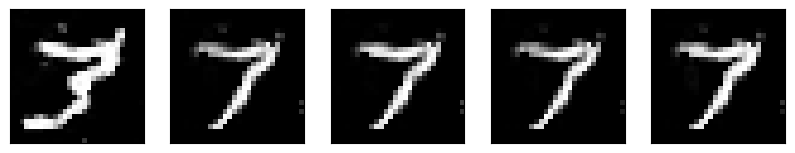

ÉPOCA 178 finalizada: Loss discriminador 0.327656 - Loss gerador 29.522154      


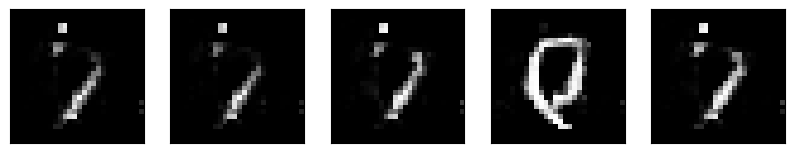

ÉPOCA 179 finalizada: Loss discriminador 0.329731 - Loss gerador 31.820321      


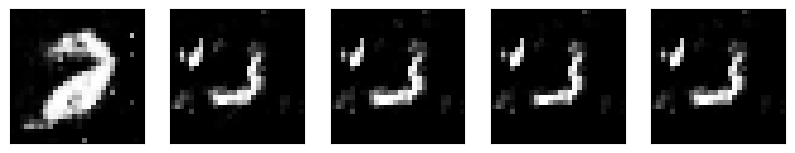

ÉPOCA 180 finalizada: Loss discriminador 0.341502 - Loss gerador 33.585123      5


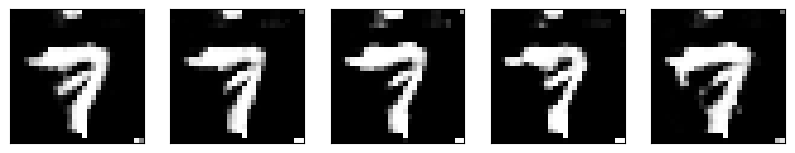

ÉPOCA 181 finalizada: Loss discriminador 0.336494 - Loss gerador 32.745264      


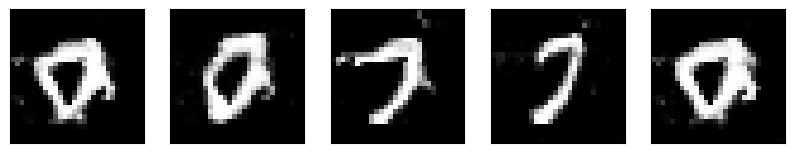

ÉPOCA 182 finalizada: Loss discriminador 0.334318 - Loss gerador 31.656127      


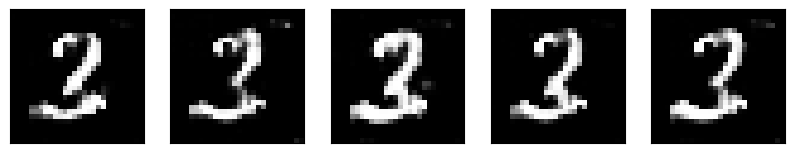

ÉPOCA 183 finalizada: Loss discriminador 0.332025 - Loss gerador 26.383475      


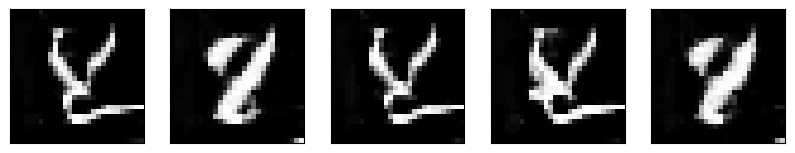

ÉPOCA 184 finalizada: Loss discriminador 0.341744 - Loss gerador 26.354748      


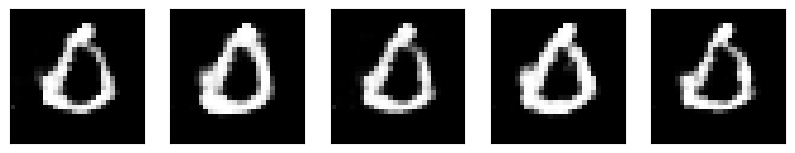

ÉPOCA 185 finalizada: Loss discriminador 0.335806 - Loss gerador 28.134745      


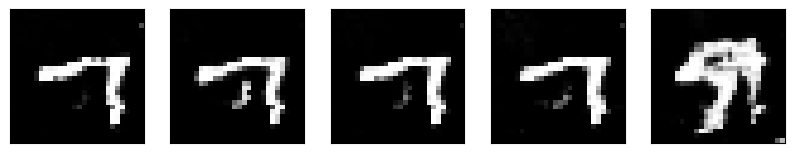

ÉPOCA 186 finalizada: Loss discriminador 0.331235 - Loss gerador 29.617722      


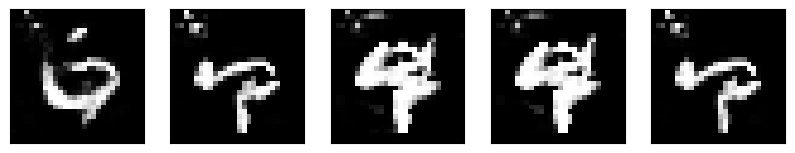

ÉPOCA 187 finalizada: Loss discriminador 0.328622 - Loss gerador 26.242112      


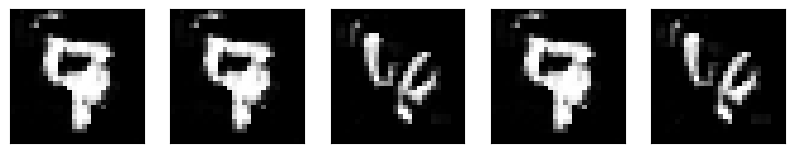

ÉPOCA 188 finalizada: Loss discriminador 0.328044 - Loss gerador 25.698373      


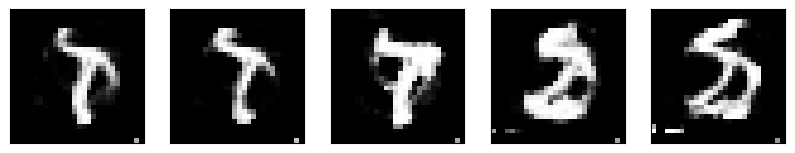

ÉPOCA 189 finalizada: Loss discriminador 0.339540 - Loss gerador 30.370729      


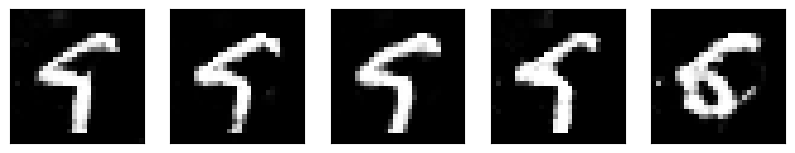

ÉPOCA 190 finalizada: Loss discriminador 0.332171 - Loss gerador 41.253592      9


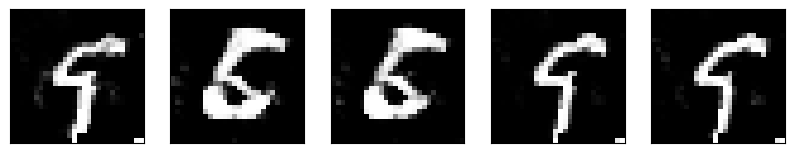

ÉPOCA 191 finalizada: Loss discriminador 0.327045 - Loss gerador 25.836542      


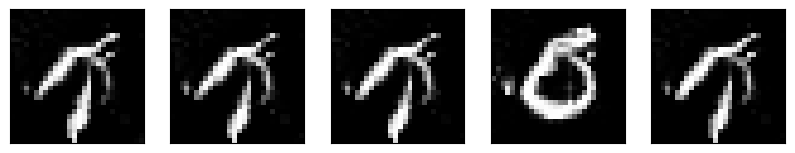

ÉPOCA 192 finalizada: Loss discriminador 0.327676 - Loss gerador 24.657977      


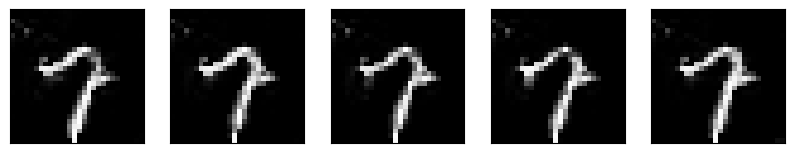

ÉPOCA 193 finalizada: Loss discriminador 0.328443 - Loss gerador 22.949239      


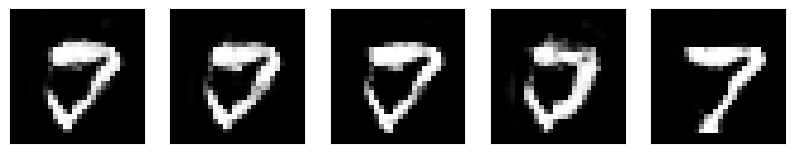

ÉPOCA 194 finalizada: Loss discriminador 0.334154 - Loss gerador 31.739782      


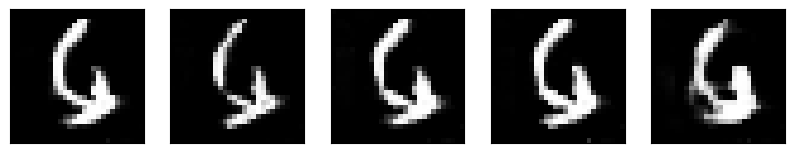

ÉPOCA 195 finalizada: Loss discriminador 0.332737 - Loss gerador 22.938641      


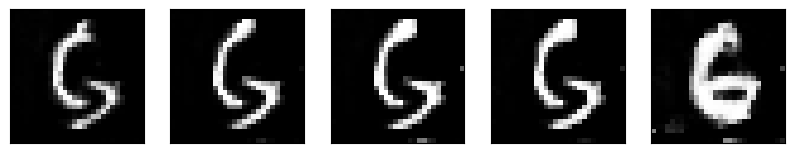

ÉPOCA 196 finalizada: Loss discriminador 0.327709 - Loss gerador 22.652523      


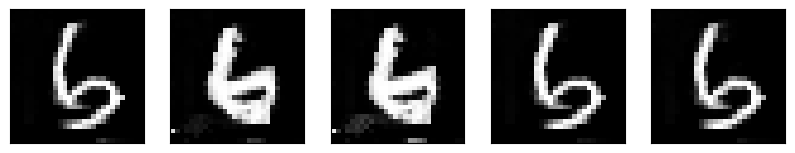

ÉPOCA 197 finalizada: Loss discriminador 0.345392 - Loss gerador 29.187567      1


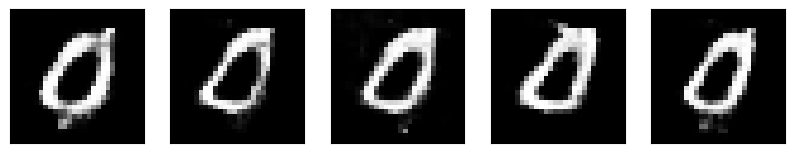

ÉPOCA 198 finalizada: Loss discriminador 0.334372 - Loss gerador 16.741315      


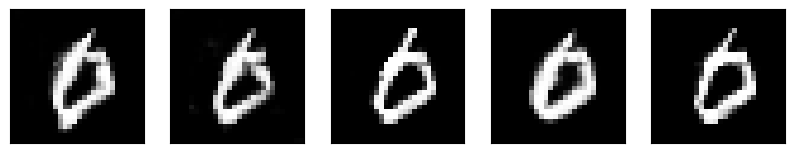

ÉPOCA 199 finalizada: Loss discriminador 0.339865 - Loss gerador 23.182159      


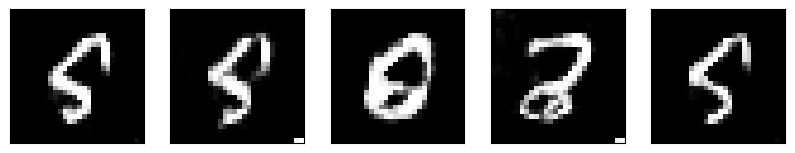

ÉPOCA 200 finalizada: Loss discriminador 0.332878 - Loss gerador 18.134874      


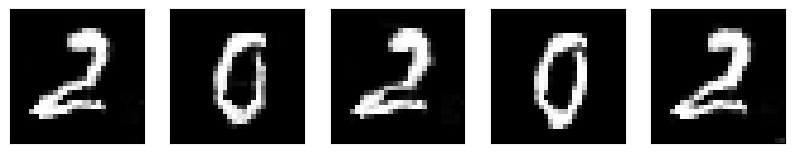

Melhor G carregado (época 141, loss 11.695903)
Melhor D carregado (época 78, loss 0.325299)


In [7]:
best_g_loss = float('inf')
best_d_loss = float('inf')
best_g_path = 'best_G.pt'
best_d_path = 'best_D.pt'

for epoch in range(200):
    D_running_loss = 0
    G_running_loss = 0
    
    for i, (imagens_reais, _) in enumerate(loader):
        batch_size = imagens_reais.size(0)

        # Imagens antes dessa transformação ficam entre 0 e 1.
        # Após a transformação, 1 continua sendo 1, e 0 vira -1.
        imagens_reais = imagens_reais * 2 - 1
        imagens_reais = imagens_reais.to(device)

        # Treinamento do gerador
        GOptimizer.zero_grad()
        # Gera uma matriz numpy com 100 ruidos por batch size, entre -1.0 e 1.0
        # O ruído é gerado centrado em 0 para estabilizar o treino,
        # Já que a saída do Gerador é uma imagem com pixels centrados em 0 (Tanh)
        # E as imagens reais também são.
        ruido = np.random.uniform(low=-1.0, high=1.0, size=(batch_size, 100))
        # Converte a matriz numpy para tensor
        ruido = torch.from_numpy(ruido).float().to(device)

        # Gera imagens falsas
        imagens_falsas = G.forward(ruido)
        # Gera o tensor de probabilidades das imagens falsas serem numeros
        outputs_falsas = D.forward(imagens_falsas)

        # Cria um tensor com batch_size 1's (Label que significa que a imagem tem um numero)
        # Isso é feito para calcular 
        labels_falsas = torch.ones(batch_size).to(device)
        
        # Como todas as imagens precisam ser de cachorros, 
        # o resultado esperado é que todas as imagens geradas pelo Gerador sejam classificadas como 1 (Presença de número na imagem)
        # pelo Discriminador. Assim, o erro do Gerador fica em função da quantidade de imagens que ele gerou,
        # Que realmente foram classificadas como números pelo Discriminador vs o caso ideal aonde todas as imagens geradas são de números.
        Gloss = criterion(outputs_falsas.view(*labels_falsas.shape), labels_falsas)
        Gloss.backward()
        GOptimizer.step()

        # Treinamento do discriminador
        DOptimizer.zero_grad()
        outputs_reais = D.forward(imagens_reais)

        labels_reais = (torch.ones(batch_size) * 0.9).to(device)
        # Treina o Discriminador para classificar as imagens reais (Cujo output idealmente é 1, mas foi suaizado sendo multiplicado por 0.9)
        # Ou seja, a partir de 0.9, o Discriminador considera que a imagem é real.
        D_loss_reais = criterion(outputs_reais.view(*labels_reais.shape), labels_reais)

        ruido = np.random.uniform(-1.0, 1.0, (batch_size, 100))
        ruido = torch.from_numpy(ruido).float().to(device)

        imagens_falsas = G.forward(ruido).detach()
        outputs_falsas = D.forward(imagens_falsas)

        labels_falsas = torch.zeros(batch_size).to(device)

        # Treina o Discriminador para classificar as imagens falsas (Cujo output idealmente é 0)
        D_loss_falsas = criterion(outputs_falsas.view(*labels_falsas.shape), labels_falsas)

        D_loss = D_loss_reais + D_loss_falsas
        D_loss.backward()
        DOptimizer.step()

        D_running_loss += D_loss.item()
        G_running_loss += Gloss.item()

        # Imprimindo os dados referentes a esse batch   
        print('\rÉpoca {:03d} - Loop {:3d} de {:3d}: Loss discriminador {:03.5f} - custo gerador {:03.5f}'.format(
            epoch + 1, i + 1, len(loader), D_loss.item(), Gloss.item()
        ), end='\r')
  
    # Imprimindo os dados referentes a essa época
    D_running_loss /= len(loader)
    G_running_loss /= len(loader)
    print('ÉPOCA {:03d} finalizada: Loss discriminador {:03.6f} - Loss gerador {:03.6f}      '.format(
        epoch + 1, D_running_loss, G_running_loss
    ))

    # Salva o melhor G e o melhor D APENAS a partir da epoch 50 (epoch >= 49)
    if epoch >= 49:
        # Salva o melhor G (menor loss do gerador)
        if G_running_loss < best_g_loss:
            best_g_loss = G_running_loss
            torch.save({
                'epoch': epoch + 1,
                'loss': best_g_loss,
                'model_state_dict': G.state_dict()
            }, best_g_path)
            print(f'Novo melhor G salvo em época {epoch + 1} com loss {best_g_loss:.6f}')

        # Salva o melhor D (menor loss do discriminador)
        if D_running_loss < best_d_loss:
            best_d_loss = D_running_loss
            torch.save({
                'epoch': epoch + 1,
                'loss': best_d_loss,
                'model_state_dict': D.state_dict()
            }, best_d_path)
            print(f'Novo melhor D salvo em época {epoch + 1} com loss {best_d_loss:.6f}')

    fig, ax = plt.subplots(1, 5, figsize=(10,5))
    for i in range(5):
      ax[i].imshow(imagens_falsas.cpu().detach().numpy()[i, 0], cmap='gray')
      ax[i].xaxis.set_visible(False)
      ax[i].yaxis.set_visible(False)
    plt.show()

# Carrega os melhores modelos ao final do treinamento
checkpoint_g = torch.load(best_g_path, map_location=device)
checkpoint_d = torch.load(best_d_path, map_location=device)

G.load_state_dict(checkpoint_g['model_state_dict'])
D.load_state_dict(checkpoint_d['model_state_dict'])

print(f"Melhor G carregado (época {checkpoint_g['epoch']}, loss {checkpoint_g['loss']:.6f})")
print(f"Melhor D carregado (época {checkpoint_d['epoch']}, loss {checkpoint_d['loss']:.6f})")

Criação de novas imagens:

In [8]:
ruido = np.random.uniform(-1.0, 1.0, (20, 100))
ruido = torch.from_numpy(ruido).float().to(device)

In [9]:
G.eval()
with torch.no_grad():
    imagem = G.forward(ruido)

imagem = imagem.cpu().detach().numpy()

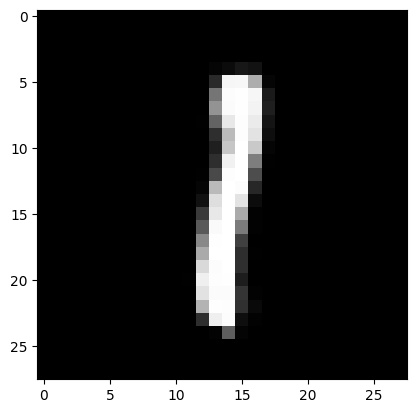

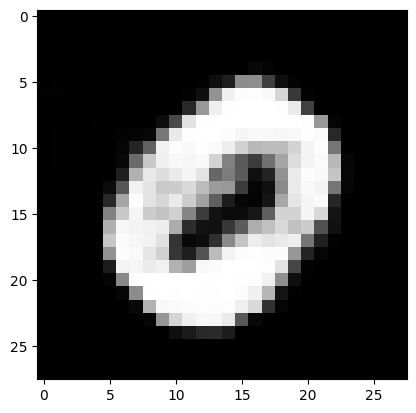

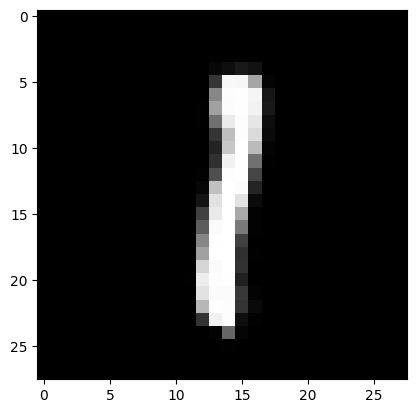

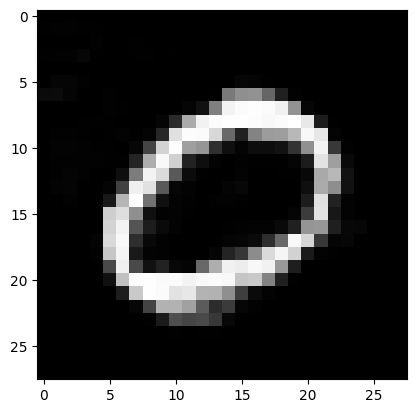

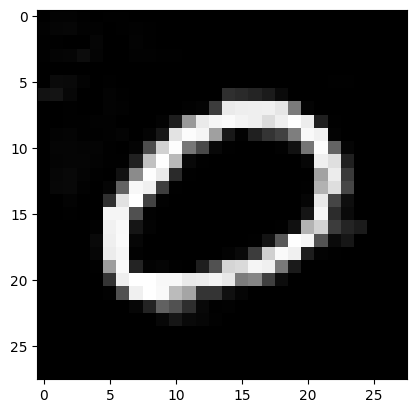

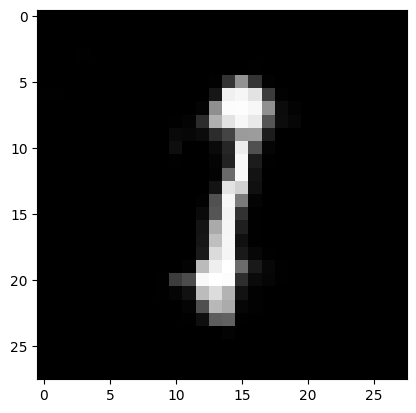

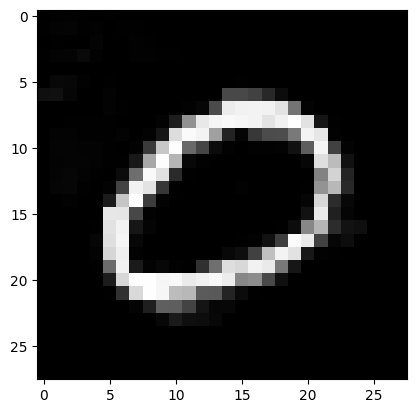

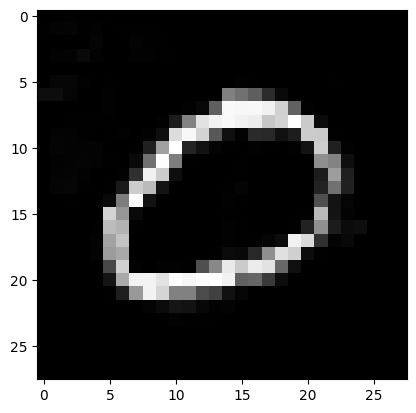

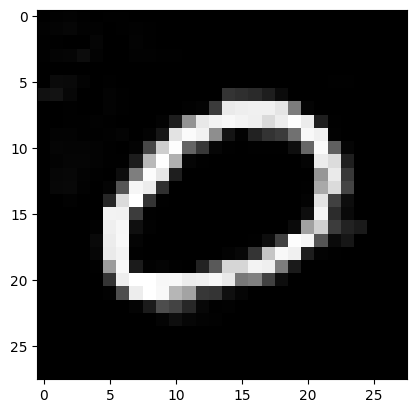

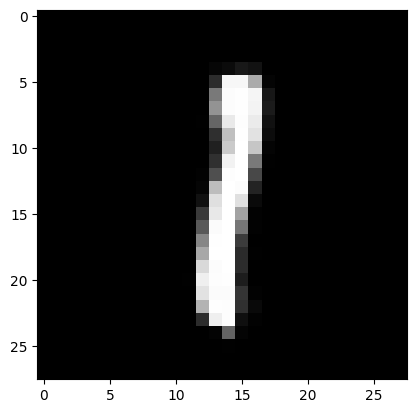

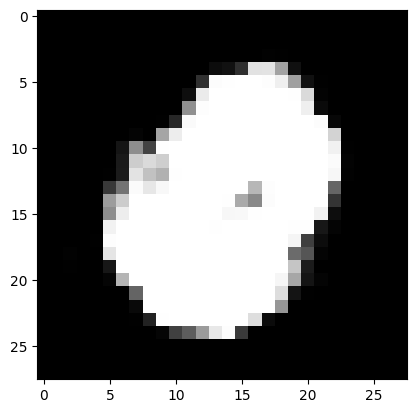

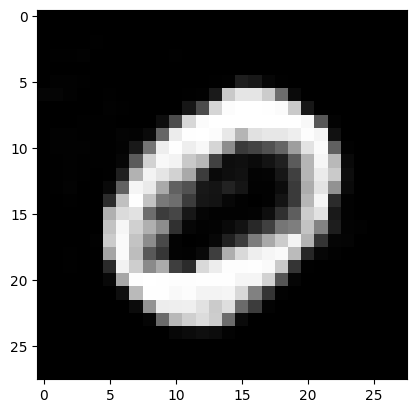

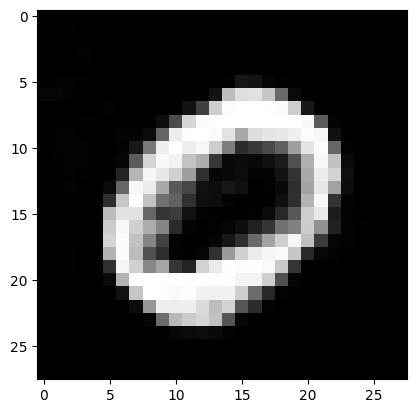

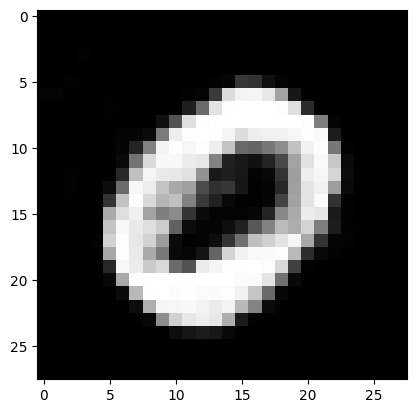

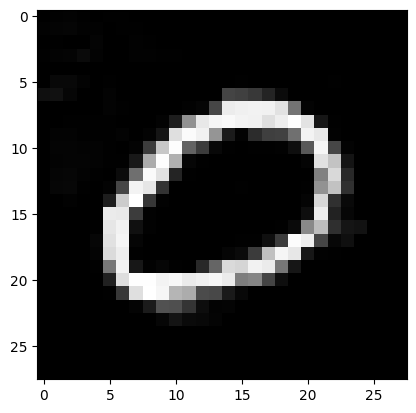

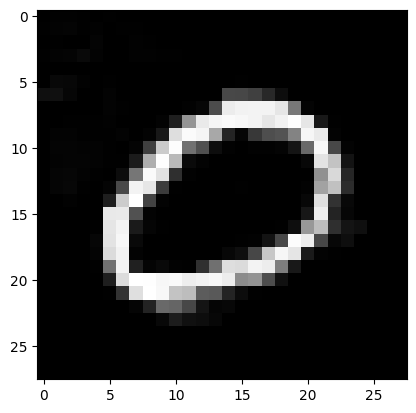

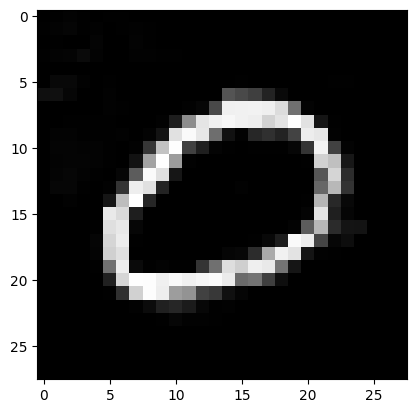

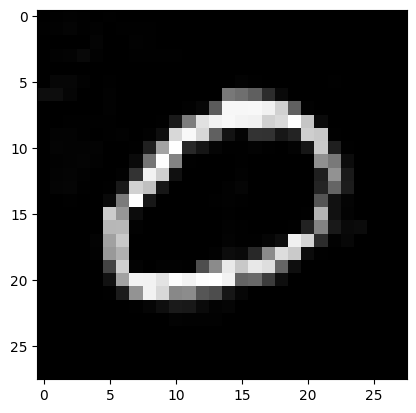

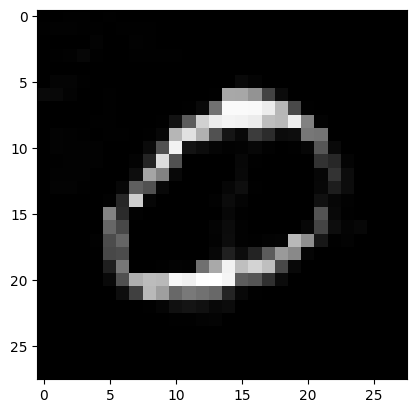

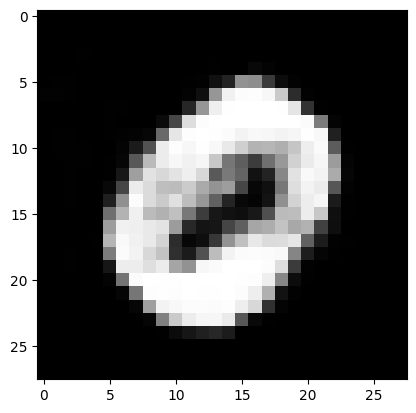

In [10]:
for i in range(imagem.shape[0]):
  plt.imshow(imagem[i, :].squeeze(), cmap='gray')
  plt.show()